# 01 — EDA avanzado · Home Credit Default Risk

**Taller B4-T1 — Diseño de Redes Confiables (Justicia e Incertidumbre)**

Este EDA no pretende describir el dataset `data/application_train.csv` (Home Credit) "en general":
es un **reconocimiento dirigido** a una pregunta concreta —*¿qué nos dicen los datos sobre cómo hay
que diseñar el modelo?*— y todo lo que sigue se subordina a las **4 tareas del taller**. En vez de
recorrer las 122 columnas, nos centramos en las 8 que el enunciado pone sobre la mesa y exprimimos
cada una hasta convertirla en una decisión de diseño. Cada bloque ejecuta código, lee los resultados
reales y cierra con conclusiones accionables ligadas a la tarea que afecta.

La pregunta de fondo que persigue el notebook: **¿de dónde sale la señal predictiva, dónde se esconde
el sesgo de género, y dónde está la incertidumbre?** Responderla es lo que justifica —y orienta— las
cuatro construcciones del taller:

| Tarea | Qué construye | Qué necesita ver el EDA |
|------|----------------|--------------------------|
| **1 — Capa custom (ratio de endeudamiento)** | división `AMT_ANNUITY/AMT_INCOME_TOTAL` + saturación `x^p` | distribuciones y sesgo de las variables financieras |
| **2 — FAIR loss** | penalizar dependencia `y_hat` ⟂ `CODE_GENDER` | desbalance de género, *group gap* base y **proxies** del género |
| **3 — Keras Tuner** | buscar topología y barrer `lambda` (Pareto precisión↔fairness) | qué señal real hay que aprovechar (variables predictivas) |
| **4 — Incertidumbre** | clase + varianza; ¿más duda donde `EXT_SOURCE` falta? | **nulos** de `EXT_SOURCE` y si la *ausencia* misma informa |

Responder esa pregunta a fondo exige más que histogramas, así que el reconocimiento despliega un
**arsenal metodológico** que se introduce justo cuando un hallazgo lo reclama: un chequeo de
**calidad de datos** que destapa valores centinela ocultos antes de que contaminen las métricas;
**medidas de dependencia más allá de Pearson** (Spearman, correlación de distancias e información
mutua) que rescatan la señal **no lineal** que una recta declara inexistente; el análisis del
**patrón de missingness** como materia prima de la incertidumbre; y la caza del **canal-proxy** por
el que el género se filtra aunque se borre la columna sensible. Cada herramienta se encadena a la
anterior, no se pega como apéndice.

> El CSV (~158 MB) **no está versionado**. Este notebook se reejecuta por cualquiera que tenga
> su propia copia en `data/application_train.csv` (ver `data/README.md`).

## Principios del EDA (tras revisar referencias)

Antes de empezar consulté referencias sobre EDA avanzado, visual y **compacto**
([Notter — *Advanced EDA*](https://miykael.github.io/blog/2022/advanced_eda/),
[AppliedAI — *EDA techniques*](https://www.appliedaicourse.com/blog/exploratory-data-analysis-techniques/),
[Analytics Insight — *10 best practices*](https://www.analyticsinsight.net/data-analysis/10-best-practices-for-exploratory-data-analysis)).
Los 5 principios que aplico:

1. **Un gráfico = una pregunta.** Nada de "gráfico por rellenar"; si no responde algo del taller, fuera.
2. **Estadística sobre el total, visual sobre muestra.** Los números (medias, nulos, correlaciones)
   sobre las 307k filas; los gráficos densos sobre muestra cuando acelera, **declarándolo**.
3. **Iterativo y dirigido.** Cada bloque usa lo que descubrió el anterior; si un número abre una
   pregunta, profundizo ahí mismo.
4. **Conclusiones accionables y numéricas.** Cada bloque cierra con "qué se ve → qué implica para
   qué tarea", citando los números reales que salieron.
5. **Exploración no destructiva.** No imputo ni transformo de forma definitiva; si propongo un
   tratamiento (log, imputación, recorte), lo dejo anotado para el preprocesado posterior.

## Bloque 1 — Carga y panorama

Lectura del CSV, dimensiones, tipos y memoria, y vista de las columnas que el taller usa.

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 30)

# --- Tema y paleta únicos para todo el notebook (claridad visual coherente) ---
sns.set_theme(style="whitegrid", palette="deep", context="notebook")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.labelsize": 10.5,
    "axes.edgecolor": "#444444",
    "axes.grid": True,
    "grid.alpha": 0.35,
    "legend.fontsize": 9,
    "legend.frameon": True,
    "legend.framealpha": 0.9,
    "xtick.labelsize": 9.5,
    "ytick.labelsize": 9.5,
    "figure.autolayout": False,
})

# Colores con SIGNIFICADO ESTABLE (mismo color = mismo concepto en todo el notebook)
C_PAGO    = "#4c72b0"   # azul  -> TARGET=0, "paga"
C_IMPAGO  = "#c44e52"   # rojo  -> TARGET=1, "impago"
C_F       = "#dd8452"   # naranja -> mujeres (F)
C_M       = "#8172b3"   # morado  -> hombres (M)
C_ACENTO  = "#55a868"   # verde -> series únicas neutras (nulos, deciles, quintiles)
C_REF     = "#555555"   # gris  -> líneas de referencia (media global, etc.)
PAL_EXT   = ["#4c72b0", "#dd8452", "#55a868"]  # EXT_SOURCE_1 / _2 / _3 (estable)

RNG = 42  # semilla para muestreo reproducible

DATA_PATH = "../data/application_train.csv"  # ajusta si ejecutas desde otra carpeta

df = pd.read_csv(DATA_PATH)

# Columnas que usa el taller (las 8 protagonistas)
KEY_COLS = ["TARGET", "CODE_GENDER",
            "AMT_INCOME_TOTAL", "AMT_ANNUITY", "AMT_CREDIT",
            "EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]

print(f"Filas x columnas : {df.shape[0]:,} x {df.shape[1]}")
print(f"Memoria en RAM   : {df.memory_usage(deep=True).sum()/1e6:,.1f} MB")
print("\nTipos de dato:")
print(df.dtypes.value_counts())
print("\nNulos globales en el dataset (top 5 columnas):")
print((df.isna().mean()*100).sort_values(ascending=False).head(5).round(1).astype(str) + " %")

Filas x columnas : 307,511 x 122
Memoria en RAM   : 341.0 MB

Tipos de dato:
float64    65
int64      41
str        16
Name: count, dtype: int64

Nulos globales en el dataset (top 5 columnas):
COMMONAREA_AVG              69.9 %
COMMONAREA_MODE             69.9 %
COMMONAREA_MEDI             69.9 %
NONLIVINGAPARTMENTS_MEDI    69.4 %
NONLIVINGAPARTMENTS_MODE    69.4 %
dtype: str


In [30]:
# Vista rápida de las columnas clave del taller
display(df[KEY_COLS].head())
df[KEY_COLS].describe(include="all").T

,TARGET,CODE_GENDER,AMT_INCOME_TOTAL,AMT_ANNUITY,AMT_CREDIT,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3
0,1,M,202500.0,24700.5,406597.5,0.083037,0.262949,0.139376
1,0,F,270000.0,35698.5,1293502.5,0.311267,0.622246,NaN
2,0,M,67500.0,6750.0,135000.0,NaN,0.555912,0.729567
3,0,F,135000.0,29686.5,312682.5,NaN,0.650442,NaN
4,0,M,121500.0,21865.5,513000.0,NaN,0.322738,NaN


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
TARGET,307511.0,NaN,NaN,NaN,0.080729,0.272419,0.0,0.0,0.0,0.0,1.0
CODE_GENDER,307511,3,F,202448,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AMT_INCOME_TOTAL,307511.0,NaN,NaN,NaN,168797.919297,237123.146279,25650.0,112500.0,147150.0,202500.0,117000000.0
AMT_ANNUITY,307499.0,NaN,NaN,NaN,27108.573909,14493.737315,1615.5,16524.0,24903.0,34596.0,258025.5
AMT_CREDIT,307511.0,NaN,NaN,NaN,599025.999706,402490.776996,45000.0,270000.0,513531.0,808650.0,4050000.0
EXT_SOURCE_1,134133.0,NaN,NaN,NaN,0.50213,0.211062,0.014568,0.334007,0.505998,0.675053,0.962693
EXT_SOURCE_2,306851.0,NaN,NaN,NaN,0.514393,0.19106,0.0,0.392457,0.565961,0.663617,0.855
EXT_SOURCE_3,246546.0,NaN,NaN,NaN,0.510853,0.194844,0.000527,0.37065,0.535276,0.669057,0.89601


### Conclusiones — Bloque 1

- **307.511 solicitudes × 122 columnas**, ~530 MB en RAM. Cabe entera en memoria: no hace falta
  trocear, pero para gráficos densos usaré muestra (principio 2).
- Tipos: **65 `float64` + 41 `int64` + 16 `object`**. Las 8 columnas del taller son numéricas salvo
  `CODE_GENDER` (categórica) y `TARGET` (entero binario).
- Hay columnas con muchísimos nulos en el dataset completo (las de edificio rondan el 50-70 %), pero
  el taller se concentra en 8 columnas: el problema de nulos relevante está **acotado a `EXT_SOURCE`**
  (Bloque 4), no es generalizado para nuestras variables.
- Las 8 columnas que pide el enunciado **existen y se llaman exactamente** como esperábamos
  (`AMT_INCOME_TOTAL`, `AMT_ANNUITY`, `AMT_CREDIT`, `EXT_SOURCE_1/2/3`) → no hay que renombrar nada.

## Bloque 1.5 — Calidad de datos (chequeo previo al modelado)

El Bloque 1 confirmó que las 8 columnas existen y tienen el tipo esperado; pero *existir* no es
*estar limpias*. Antes de exprimir cada variable conviene un **chequeo de calidad** de las columnas
que tocaremos: categorías anómalas, outliers, **valores centinela** ocultos y qué variables piden
transformación. Si no se detectan, contaminan distribuciones y métricas en las 4 tareas. Es
exploración **no destructiva**: anotamos el tratamiento, no lo aplicamos aquí.

In [31]:
# --- Chequeo de calidad sobre las columnas que usaremos (estadística sobre el TOTAL) ---
# 1) Categoría anómala de género (XNA)
n_xna = int((df["CODE_GENDER"] == "XNA").sum())
print(f"CODE_GENDER == XNA : {n_xna} registros ({n_xna/len(df)*100:.4f}% del total)")

# 2) Outlier extremo de ingreso
inc = df["AMT_INCOME_TOTAL"]
print(f"\nAMT_INCOME_TOTAL  : max={inc.max():,.0f}  p99.9={inc.quantile(0.999):,.0f}  "
      f"-> max = {inc.max()/inc.quantile(0.999):.0f}x el p99.9")
print(f"                    ingreso > 10M: {(inc>1e7).sum()} solicitudes | == max: {(inc==inc.max()).sum()}")

# 3) VALOR CENTINELA oculto en DAYS_EMPLOYED (código 'no aplica' de Home Credit)
de = df["DAYS_EMPLOYED"]; SENT = 365243
n_sent = int((de == SENT).sum())
print(f"\nDAYS_EMPLOYED centinela {SENT} (~{SENT/365.25:.0f} años, imposible):")
print(f"   filas afectadas     : {n_sent:,} ({n_sent/len(df)*100:.2f}% del total)")
print(f"   max real / min real : {de[de!=SENT].max():,} / {de.min():,}")
print(f"   tasa impago centinela {df.loc[de==SENT,'TARGET'].mean()*100:.2f}% "
      f"vs resto {df.loc[de!=SENT,'TARGET'].mean()*100:.2f}%")
print(f"   NAME_INCOME_TYPE (top): {df.loc[de==SENT,'NAME_INCOME_TYPE'].value_counts().head(2).to_dict()}")

# 4) Columnas con nulos extremos en TODO el dataset
miss_all = df.isna().mean() * 100
print(f"\nColumnas con > 50% nulos: {(miss_all>50).sum()} de {df.shape[1]}  "
      f"(> 30%: {(miss_all>30).sum()})")

# 5) Asimetría de las financieras (justifica transformación log)
sk = df[["AMT_INCOME_TOTAL", "AMT_ANNUITY", "AMT_CREDIT"]].skew()
print("\nAsimetría (skew):", {k: round(v, 1) for k, v in sk.items()})

CODE_GENDER == XNA : 4 registros (0.0013% del total)

AMT_INCOME_TOTAL  : max=117,000,000  p99.9=900,000  -> max = 130x el p99.9
                    ingreso > 10M: 3 solicitudes | == max: 1

DAYS_EMPLOYED centinela 365243 (~1000 años, imposible):
   filas afectadas     : 55,374 (18.01% del total)
   max real / min real : 0 / -17,912
   tasa impago centinela 5.40% vs resto 8.66%
   NAME_INCOME_TYPE (top): {'Pensioner': 55352, 'Unemployed': 22}

Columnas con > 50% nulos: 41 de 122  (> 30%: 50)

Asimetría (skew): {'AMT_INCOME_TOTAL': 391.6, 'AMT_ANNUITY': 1.6, 'AMT_CREDIT': 1.2}


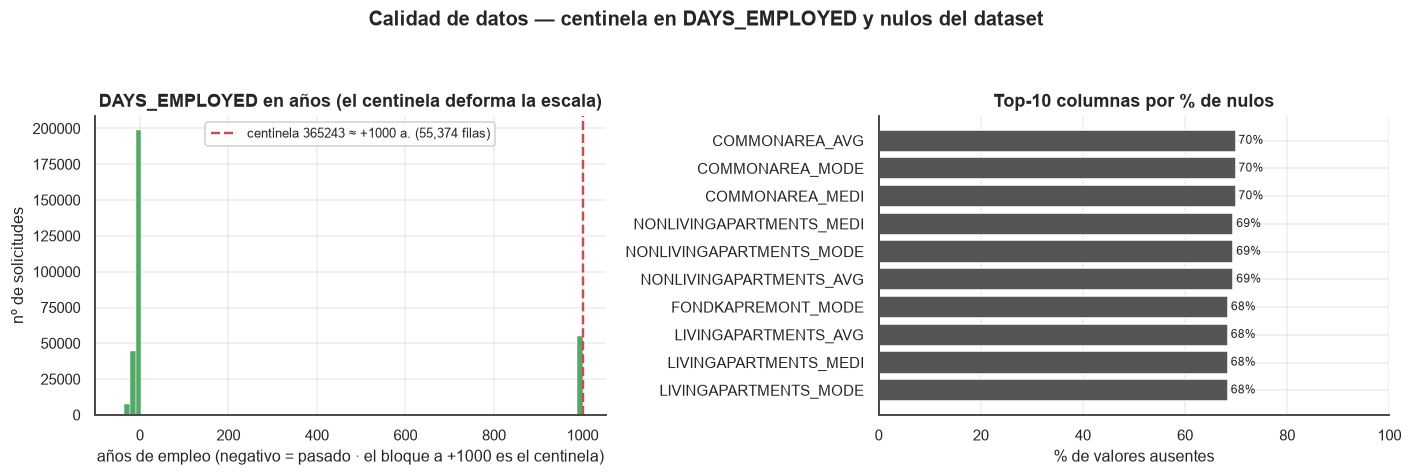

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
fig.suptitle("Calidad de datos — centinela en DAYS_EMPLOYED y nulos del dataset",
             fontsize=13, fontweight="bold")

# (a) DAYS_EMPLOYED en años: el centinela 365243 crea un pico imposible a ~+1000 años
yrs = df["DAYS_EMPLOYED"] / 365.25
axes[0].hist(yrs, bins=80, color=C_ACENTO, edgecolor="white", linewidth=0.3)
axes[0].axvline(SENT / 365.25, ls="--", c=C_IMPAGO, lw=1.6,
                label=f"centinela 365243 ≈ +{SENT/365.25:.0f} a. ({n_sent:,} filas)")
axes[0].set_title("DAYS_EMPLOYED en años (el centinela deforma la escala)")
axes[0].set_xlabel("años de empleo (negativo = pasado · el bloque a +1000 es el centinela)")
axes[0].set_ylabel("nº de solicitudes")
axes[0].legend(loc="upper center", fontsize=8.5)

# (b) top-10 columnas por % de nulos
topn = miss_all.sort_values(ascending=False).head(10)
b = axes[1].barh(topn.index[::-1], topn.values[::-1], color=C_REF, edgecolor="white")
axes[1].bar_label(b, fmt="%.0f%%", padding=2, fontsize=8)
axes[1].set_title("Top-10 columnas por % de nulos")
axes[1].set_xlabel("% de valores ausentes")
axes[1].set_xlim(0, 100)

for ax in axes:
    sns.despine(ax=ax)
plt.tight_layout(rect=(0, 0, 1, 0.93)); plt.show()

### Conclusiones — Bloque 1.5 (calidad de datos)

- **Centinela oculto en `DAYS_EMPLOYED` = 365243** (≈1000 años en el futuro, código "no aplica" de Home Credit): aparece en **55.374 filas (18,01 %)**, casi todas **pensionistas/desempleados**. Sin tratarlo, mete un pico imposible que destroza cualquier normalización de antigüedad laboral. Ese grupo además impaga **menos** (5,40 % vs 8,66 % el resto) por ser pensionistas → la *ausencia de empleo* informa. **Tratamiento propuesto:** convertir 365243 → `NaN` (+ flag binario) antes de modelar.
- **`CODE_GENDER == XNA`: 4 registros (0,0013 %).** Irrelevantes en volumen pero rompen un sensible binario limpio para la **Tarea 2** → descartar o imputar en preprocesado.
- **Outlier de ingreso: máx 117.000.000 = 130× el p99.9**, caso único (3 casos > 10M). Junto al **skew ≈ 392** del ingreso, es justo lo que motiva la saturación `x^p` / log de la **Tarea 1**.
- **41 de 122 columnas superan el 50 % de nulos** (50 superan el 30 %), casi todas de edificio; de nuestras 8 protagonistas solo `EXT_SOURCE` sufre nulos (Bloque 4) → el problema de missingness está acotado.
- **Transformación log recomendada (skew real):** `AMT_INCOME_TOTAL` skew **391,6** → log/winsorize imprescindible; `AMT_ANNUITY` **1,6** y `AMT_CREDIT` **1,2** → log opcional (cola moderada). Esto alimenta la decisión sobre la capa de saturación (Tarea 1).

## Bloque 2 — Variable objetivo `TARGET`

Confirmado que las 8 columnas están y son del tipo esperado, empezamos por lo que todo lo demás
intenta predecir. `TARGET = 1` → dificultades de pago (impago); `0` → pagó a tiempo. Medimos el
desbalance, porque es lo primero que condiciona qué métricas valen y cómo hay que entrenar en
**todas** las tareas.

Clase 0 (pago)   : 282,686  (91.93 %)
Clase 1 (impago) : 24,825  (8.07 %)
Ratio negativos:positivos = 11.4 : 1


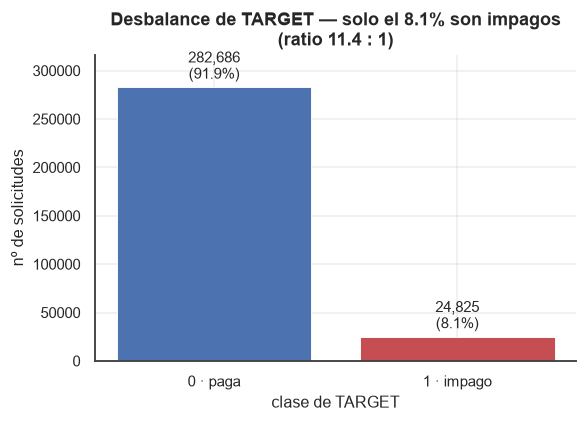

In [33]:
counts = df["TARGET"].value_counts().sort_index()
rate = df["TARGET"].mean()
ratio = counts[0] / counts[1]
print(f"Clase 0 (pago)   : {counts[0]:,}  ({(1-rate)*100:.2f} %)")
print(f"Clase 1 (impago) : {counts[1]:,}  ({rate*100:.2f} %)")
print(f"Ratio negativos:positivos = {ratio:.1f} : 1")

fig, ax = plt.subplots(figsize=(5.5, 4))
bars = ax.bar(["0 · paga", "1 · impago"], counts.values,
              color=[C_PAGO, C_IMPAGO], edgecolor="white", linewidth=0.6)
# Etiqueta cada barra con recuento y % sobre el total
pct = [(1-rate)*100, rate*100]
ax.bar_label(bars, labels=[f"{v:,.0f}\n({p:.1f}%)" for v, p in zip(counts.values, pct)],
             padding=3, fontsize=9.5)
ax.set_title(f"Desbalance de TARGET — solo el {rate*100:.1f}% son impagos\n(ratio {ratio:.1f} : 1)")
ax.set_xlabel("clase de TARGET")
ax.set_ylabel("nº de solicitudes")
ax.set_ylim(0, counts.max() * 1.12)
sns.despine(ax=ax)
plt.tight_layout(); plt.show()

### Conclusiones — Bloque 2

- Desbalance fuerte: **8,07 % de impagos** frente a 91,93 % → **ratio ≈ 11,4 : 1**.
- **Implicación para métricas (Tareas 2, 3 y 4):** la *accuracy* engaña — un modelo trivial que
  prediga siempre "paga" acierta el **91,9 %** sin aprender nada. Hay que mirar **AUC-ROC**
  (métrica oficial de Home Credit), y para el negocio **recall/precision sobre la clase impago**
  (los positivos son los caros). Esto fija el eje *Precisión* de la curva de Pareto de la Tarea 3.
- **Implicación para entrenamiento:** conviene `class_weight` (o reponderar la BCE) para que el
  11,4:1 no haga que la red ignore la clase minoritaria. Se deja anotado para el modelado.
- **Implicación para la Tarea 4:** la clase minoritaria (impago) tendrá menos ejemplos → es de
  esperar **más incertidumbre epistémica** ahí; el gráfico "buen vs mal pagador" de la varianza
  debería notarlo.

## Bloque 3 — Variable sensible `CODE_GENDER` (corazón de la Tarea 2)

Sabiendo ya que la clase positiva es rara (8 %), la siguiente pregunta es de quién es ese impago. El
modelo **no debe discriminar por género**, pero antes de "arreglar" nada hay que medir el sesgo que
ya traen los datos: ¿difiere la tasa de impago entre hombres y mujeres? Ese es el *group gap* de
partida que la FAIR loss tendrá que vigilar para no amplificar —y la cifra contra la que mediremos
nuestro entregable de justicia.

Distribución de CODE_GENDER (incluye categoría anómala):
CODE_GENDER
F      202448
M      105059
XNA         4
Name: count, dtype: int64

Tasa de impago por género (sin XNA):
                  n  tasa_impago_%
CODE_GENDER                       
F            202448           7.00
M            105059          10.14

Group gap base (M - F): +3.14 puntos porcentuales  |  M/F = 1.45x


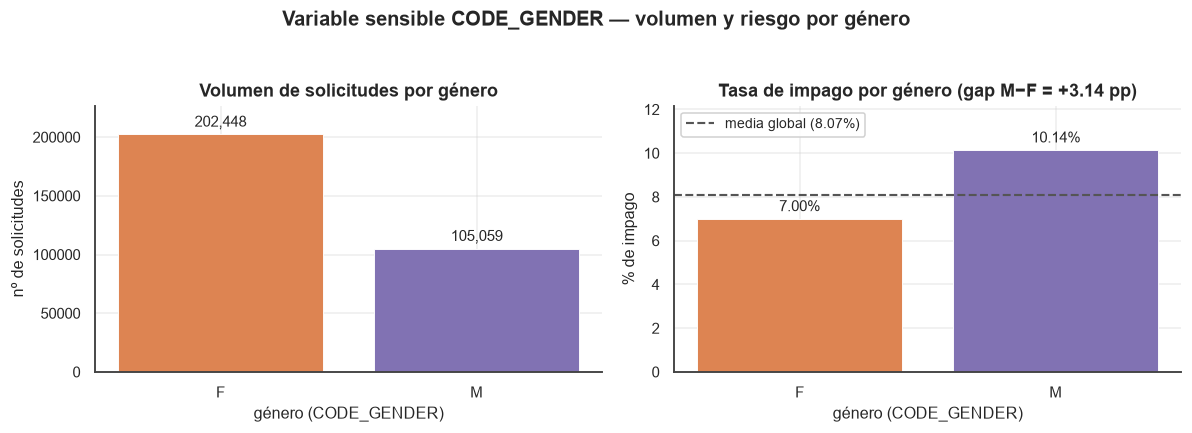

In [34]:
print("Distribución de CODE_GENDER (incluye categoría anómala):")
print(df["CODE_GENDER"].value_counts(dropna=False))

# XNA: solo unos pocos registros sin género informado -> los aislamos
g = df[df["CODE_GENDER"].isin(["F", "M"])]
by_gender = g.groupby("CODE_GENDER")["TARGET"].agg(n="count", tasa_impago="mean")
by_gender["tasa_impago_%"] = (by_gender["tasa_impago"]*100).round(2)
print("\nTasa de impago por género (sin XNA):")
print(by_gender[["n", "tasa_impago_%"]])

gap = (by_gender.loc["M", "tasa_impago"] - by_gender.loc["F", "tasa_impago"]) * 100
rel = by_gender.loc["M", "tasa_impago"] / by_gender.loc["F", "tasa_impago"]
print(f"\nGroup gap base (M - F): {gap:+.2f} puntos porcentuales  |  M/F = {rel:.2f}x")

# Color FIJO por género (F=naranja, M=morado) usado igual en todo el notebook
GEN_COLORS = {"F": C_F, "M": C_M}

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle("Variable sensible CODE_GENDER — volumen y riesgo por género",
             fontsize=13, fontweight="bold")

# (a) Volumen por género
counts_g = g["CODE_GENDER"].value_counts()
b0 = axes[0].bar(counts_g.index, counts_g.values,
                 color=[GEN_COLORS[k] for k in counts_g.index],
                 edgecolor="white", linewidth=0.6)
axes[0].bar_label(b0, fmt="{:,.0f}", padding=3, fontsize=9.5)
axes[0].set_title("Volumen de solicitudes por género")
axes[0].set_xlabel("género (CODE_GENDER)")
axes[0].set_ylabel("nº de solicitudes")
axes[0].set_ylim(0, counts_g.max() * 1.12)

# (b) Tasa de impago por género + media global de referencia
b1 = axes[1].bar(by_gender.index, by_gender["tasa_impago_%"],
                 color=[GEN_COLORS[k] for k in by_gender.index],
                 edgecolor="white", linewidth=0.6)
axes[1].bar_label(b1, fmt="%.2f%%", padding=3, fontsize=9.5)
axes[1].axhline(df["TARGET"].mean()*100, ls="--", c=C_REF, lw=1.4,
                label=f"media global ({df['TARGET'].mean()*100:.2f}%)")
axes[1].set_title(f"Tasa de impago por género (gap M−F = {gap:+.2f} pp)")
axes[1].set_xlabel("género (CODE_GENDER)")
axes[1].set_ylabel("% de impago")
axes[1].set_ylim(0, by_gender["tasa_impago_%"].max() * 1.20)
axes[1].legend(loc="upper left")

for ax in axes:
    sns.despine(ax=ax)
plt.tight_layout(rect=(0, 0, 1, 0.95)); plt.show()

### Conclusiones — Bloque 3

- Reparto **F 202.448 / M 105.059** (las mujeres son ~2/3 de la cartera) + **4 registros `XNA`**
  (género no informado). Los 4 `XNA` se aíslan del análisis de equidad; en el preprocesado habrá que
  decidir si se descartan o imputan (son irrelevantes en volumen, pero romperían un `CODE_GENDER`
  binario limpio para la Tarea 2).
- **Group gap base real: los hombres impagan 10,14 % vs 7,00 % las mujeres → +3,14 puntos
  (M es 1,45× el riesgo de F).** El sesgo **existe en los datos**, no lo inventa el modelo.
- **Implicación directa para la Tarea 2:** este gap es la línea base que documentar. Un modelo sin
  restricción aprenderá a reproducir (o amplificar) esa diferencia → la FAIR loss penaliza
  `Dep(y_hat, CODE_GENDER)` y el entregable de justicia es el **group gap de las predicciones**
  comparado con este 3,14 pp de partida.
- **Aviso metodológico (también Tarea 2):** como `CODE_GENDER` es **binaria**, las medidas kernel
  (CKA) "apenas registran" el desplazamiento de medias; lo natural aquí es **penalizar con
  correlación/HSIC pero reportar el group gap** como métrica de fairness legible.

## Bloque 4 — `EXT_SOURCE_1/2/3` (clave para la Tarea 4)

Detectado un sesgo de género real, falta saber de qué señal vive realmente el modelo —y ahí entran
las fuentes externas. Son scores de terceros, **las variables más predictivas** del problema y, a la
vez, las que más **nulos** acumulan (que el enunciado dice que se imputan). Analizo: % de nulos,
distribución, correlación con `TARGET` y entre ellas, y —crucial para la incertidumbre— creo **flags
de ausencia ANTES de imputar** para comprobar si el simple hecho de *faltar* ya informa del impago.

In [35]:
EXT = ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]

# 1) Nulos y correlación con TARGET (sobre no-nulos)
miss = (df[EXT].isna().mean()*100).round(2)
corr_t = df[EXT + ["TARGET"]].corr()["TARGET"].drop("TARGET").round(3)
resumen = pd.DataFrame({"% nulos": miss, "corr con TARGET": corr_t})
print(resumen)
print("\nCorrelación entre las EXT_SOURCE (redundantes o complementarias?):")
print(df[EXT].corr().round(3))

# 2) Flags de ausencia ANTES de imputar (no destructivo: columnas nuevas)
for c in EXT:
    df[c + "_missing"] = df[c].isna().astype(int)
df["N_EXT_MISSING"] = df[[c + "_missing" for c in EXT]].sum(axis=1)

print("\nTasa de impago según FALTE cada EXT_SOURCE:")
for c in EXT:
    m = df[c].isna()
    print(f"  {c}: falta -> {df.loc[m,'TARGET'].mean()*100:5.2f}% | presente -> {df.loc[~m,'TARGET'].mean()*100:5.2f}%")

print("\nTasa de impago según nº de EXT_SOURCE ausentes:")
print((df.groupby('N_EXT_MISSING')['TARGET'].agg(n='count', tasa='mean')
         .assign(**{'tasa_%': lambda d: (d['tasa']*100).round(2)})[['n','tasa_%']]))

              % nulos  corr con TARGET
EXT_SOURCE_1    56.38           -0.155
EXT_SOURCE_2     0.21           -0.160
EXT_SOURCE_3    19.83           -0.179

Correlación entre las EXT_SOURCE (redundantes o complementarias?):
              EXT_SOURCE_1  EXT_SOURCE_2  EXT_SOURCE_3
EXT_SOURCE_1         1.000         0.214         0.187
EXT_SOURCE_2         0.214         1.000         0.109
EXT_SOURCE_3         0.187         0.109         1.000

Tasa de impago según FALTE cada EXT_SOURCE:
  EXT_SOURCE_1: falta ->  8.52% | presente ->  7.50%
  EXT_SOURCE_2: falta ->  7.88% | presente ->  8.07%
  EXT_SOURCE_3: falta ->  9.31% | presente ->  7.77%

Tasa de impago según nº de EXT_SOURCE ausentes:
                    n  tasa_%
N_EXT_MISSING                
0              109589    7.30
1              161013    8.18
2               36737    9.92
3                 172    8.14


C:\Users\gonde\AppData\Local\Temp\ipykernel_32608\1361390695.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[c + "_missing"] = df[c].isna().astype(int)
C:\Users\gonde\AppData\Local\Temp\ipykernel_32608\1361390695.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[c + "_missing"] = df[c].isna().astype(int)
C:\Users\gonde\AppData\Local\Temp\ipykernel_32608\1361390695.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance. 

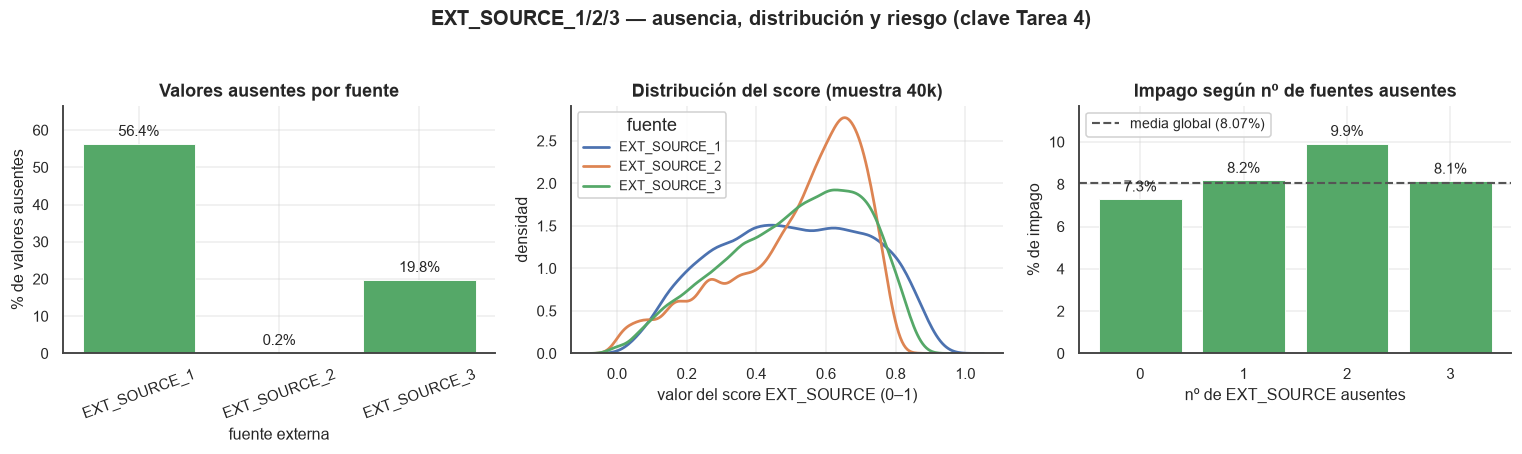

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
fig.suptitle("EXT_SOURCE_1/2/3 — ausencia, distribución y riesgo (clave Tarea 4)",
             fontsize=13, fontweight="bold")

# (a) % de nulos por fuente
b = axes[0].bar(EXT, miss.values, color=C_ACENTO, edgecolor="white", linewidth=0.6)
axes[0].bar_label(b, fmt="%.1f%%", padding=3, fontsize=9.5)
axes[0].set_title("Valores ausentes por fuente")
axes[0].set_xlabel("fuente externa")
axes[0].set_ylabel("% de valores ausentes")
axes[0].set_ylim(0, max(miss.values) * 1.18)
axes[0].tick_params(axis="x", rotation=20)

# (b) distribución del score por fuente (muestra para el KDE; declarado)
samp = df.sample(40000, random_state=RNG)
for c, col in zip(EXT, PAL_EXT):
    sns.kdeplot(data=samp, x=c, ax=axes[1], label=c, color=col, lw=1.8)
axes[1].set_title("Distribución del score (muestra 40k)")
axes[1].set_xlabel("valor del score EXT_SOURCE (0–1)")
axes[1].set_ylabel("densidad")
axes[1].legend(title="fuente", fontsize=8.5)

# (c) tasa de impago según nº de EXT ausentes
gm = df.groupby("N_EXT_MISSING")["TARGET"].mean()*100
b2 = axes[2].bar(gm.index.astype(str), gm.values,
                 color=C_ACENTO, edgecolor="white", linewidth=0.6)
axes[2].bar_label(b2, fmt="%.1f%%", padding=3, fontsize=9.5)
axes[2].axhline(df["TARGET"].mean()*100, ls="--", c=C_REF, lw=1.4,
                label=f"media global ({df['TARGET'].mean()*100:.2f}%)")
axes[2].set_title("Impago según nº de fuentes ausentes")
axes[2].set_xlabel("nº de EXT_SOURCE ausentes")
axes[2].set_ylabel("% de impago")
axes[2].set_ylim(0, max(gm.values) * 1.18)
axes[2].legend(loc="upper left")

for ax in axes:
    sns.despine(ax=ax)
plt.tight_layout(rect=(0, 0, 1, 0.95)); plt.show()

Tasa de impago por decil de EXT_SOURCE (solo valores presentes):
  EXT_SOURCE_2: D1=18.4%  ...  D10=3.0%  | ratio D1/D10 = 6.2x
  EXT_SOURCE_3: D1=20.0%  ...  D10=3.2%  | ratio D1/D10 = 6.2x


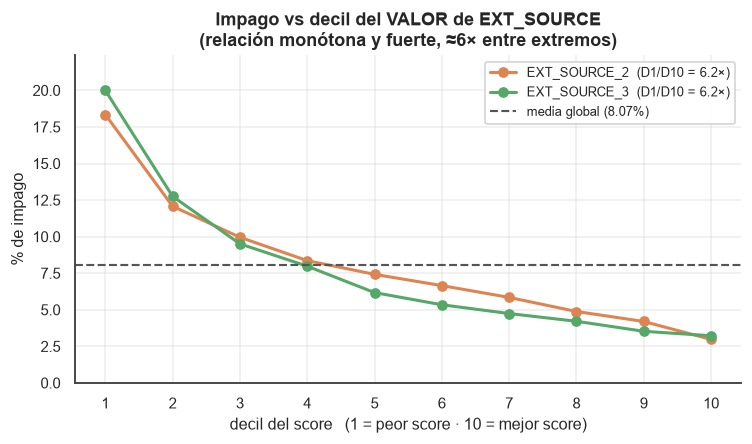

In [37]:
# Separar el efecto del VALOR de EXT_SOURCE (no su ausencia): tasa de impago por decil
# del score (solo no-nulos). EXT_SOURCE_2 y _3 son las más completas y predictivas.
print("Tasa de impago por decil de EXT_SOURCE (solo valores presentes):")
shape = {}
for c in ["EXT_SOURCE_2", "EXT_SOURCE_3"]:
    d = df.loc[df[c].notna(), [c, "TARGET"]].copy()
    d["dec"] = pd.qcut(d[c], 10, labels=False, duplicates="drop")
    t = d.groupby("dec")["TARGET"].mean() * 100
    shape[c] = t
    print(f"  {c}: D1={t.iloc[0]:.1f}%  ...  D10={t.iloc[-1]:.1f}%  "
          f"| ratio D1/D10 = {t.iloc[0]/t.iloc[-1]:.1f}x")

# Color estable por fuente (mismo que en el panel de distribución)
LINE_COLORS = {"EXT_SOURCE_2": PAL_EXT[1], "EXT_SOURCE_3": PAL_EXT[2]}

fig, ax = plt.subplots(figsize=(7, 4.2))
for c, t in shape.items():
    ax.plot(range(1, len(t)+1), t.values, marker="o", lw=2,
            color=LINE_COLORS[c], label=f"{c}  (D1/D10 = {t.iloc[0]/t.iloc[-1]:.1f}×)")
ax.axhline(df["TARGET"].mean()*100, ls="--", c=C_REF, lw=1.4,
           label=f"media global ({df['TARGET'].mean()*100:.2f}%)")
ax.set_title("Impago vs decil del VALOR de EXT_SOURCE\n(relación monótona y fuerte, ≈6× entre extremos)")
ax.set_xlabel("decil del score   (1 = peor score · 10 = mejor score)")
ax.set_ylabel("% de impago")
ax.set_xticks(range(1, 11))
ax.set_ylim(0, max(t.max() for t in shape.values()) * 1.12)
ax.legend(fontsize=8.5)
sns.despine(ax=ax)
plt.tight_layout(); plt.show()

### Patrón de nulos y co-ausencia de `EXT_SOURCE` (clave Tarea 4)

El bloque ya vio *cuántos* nulos hay y que la ausencia predice impago. Ahora miramos el **patrón**:
¿qué columnas tienen huecos y faltan alineadas?, ¿las `EXT_SOURCE` faltan **juntas** (un mismo
solicitante sin fuentes) o de forma independiente?, y ¿cómo de fiable es la tasa de impago por decil
(**banda de confianza**) —anticipo de dónde el modelo debería dudar (Tarea 4)?

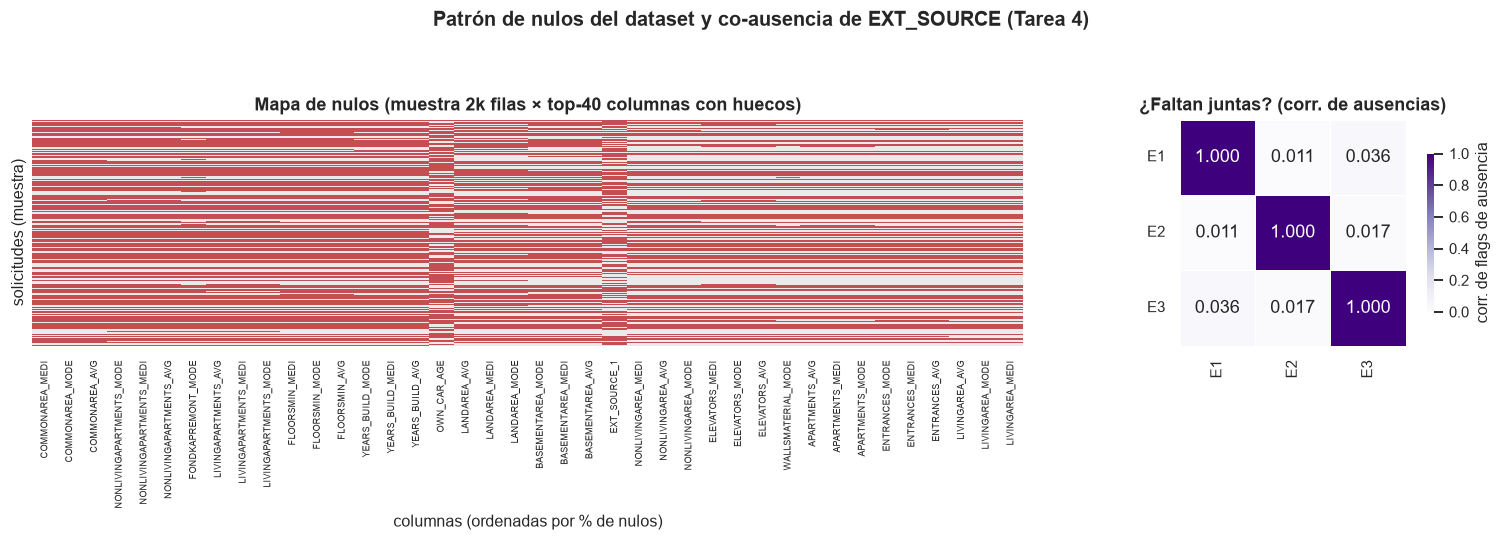

Solicitudes con EXT_SOURCE_1 y _3 ausentes a la vez: 36,574 (11.9%)  |  corr de sus flags = 0.036


In [38]:
from matplotlib.colors import ListedColormap

# (a) Mapa de calor de nulos (muestra de filas) + (b) co-ausencia entre EXT_SOURCE
samp_rows = df.sample(2000, random_state=RNG)
cols_na = miss_all[miss_all > 0].sort_values(ascending=False).head(40).index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(14, 5),
                         gridspec_kw={"width_ratios": [2.4, 1]})
fig.suptitle("Patrón de nulos del dataset y co-ausencia de EXT_SOURCE (Tarea 4)",
             fontsize=13, fontweight="bold")

# mapa de nulos: gris = presente, rojo = ausente
sns.heatmap(samp_rows[cols_na].isna(), cbar=False, ax=axes[0],
            cmap=ListedColormap(["#eaeaea", C_IMPAGO]))
axes[0].set_title("Mapa de nulos (muestra 2k filas × top-40 columnas con huecos)")
axes[0].set_xlabel("columnas (ordenadas por % de nulos)")
axes[0].set_ylabel("solicitudes (muestra)")
axes[0].set_yticks([])
axes[0].tick_params(axis="x", labelsize=6, rotation=90)

# co-missingness entre flags de ausencia de EXT_SOURCE
co = df[[c + "_missing" for c in EXT]].corr()
co.index = EXT; co.columns = EXT
sns.heatmap(co, annot=True, fmt=".3f", cmap="Purples", vmin=0, vmax=1,
            square=True, linewidths=0.5, linecolor="white",
            cbar_kws={"shrink": .7, "label": "corr. de flags de ausencia"}, ax=axes[1])
axes[1].set_title("¿Faltan juntas? (corr. de ausencias)")
axes[1].set_xticklabels(["E1", "E2", "E3"]); axes[1].set_yticklabels(["E1", "E2", "E3"], rotation=0)
plt.tight_layout(rect=(0, 0, 1, 0.93)); plt.show()

both13 = int(((df["EXT_SOURCE_1"].isna()) & (df["EXT_SOURCE_3"].isna())).sum())
print(f"Solicitudes con EXT_SOURCE_1 y _3 ausentes a la vez: {both13:,} "
      f"({both13/len(df)*100:.1f}%)  |  corr de sus flags = {co.loc['EXT_SOURCE_1','EXT_SOURCE_3']:.3f}")

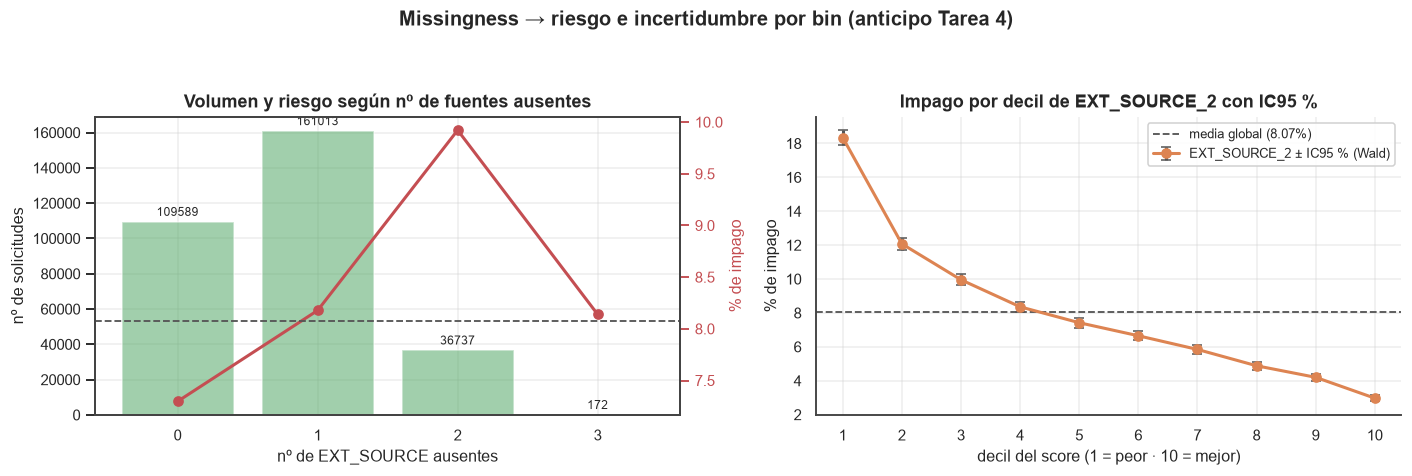

IC95 % D1: 18.35% ± 0.43  | D10: 2.97% ± 0.19


In [39]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
fig.suptitle("Missingness → riesgo e incertidumbre por bin (anticipo Tarea 4)",
             fontsize=13, fontweight="bold")

# (a) volumen por nº de EXT ausentes (barras) + tasa de impago (línea, eje secundario)
agg = df.groupby("N_EXT_MISSING")["TARGET"].agg(n="count", rate="mean")
ax0 = axes[0]
b = ax0.bar(agg.index.astype(str), agg["n"], color=C_ACENTO, alpha=.55,
            edgecolor="white", label="nº de solicitudes")
ax0.bar_label(b, fmt="%.0f", padding=2, fontsize=8)
ax0.set_xlabel("nº de EXT_SOURCE ausentes"); ax0.set_ylabel("nº de solicitudes")
ax0.set_title("Volumen y riesgo según nº de fuentes ausentes")
ax0b = ax0.twinx()
ax0b.plot(agg.index.astype(str), agg["rate"]*100, color=C_IMPAGO, marker="o", lw=2,
          label="tasa de impago")
ax0b.axhline(df["TARGET"].mean()*100, ls="--", c=C_REF, lw=1.2)
ax0b.set_ylabel("% de impago", color=C_IMPAGO)
ax0b.tick_params(axis="y", colors=C_IMPAGO)
ax0b.grid(False)

# (b) tasa de impago por decil de EXT_SOURCE_2 con banda de confianza Wald 95%
c = "EXT_SOURCE_2"
dd = df.loc[df[c].notna(), [c, "TARGET"]].copy()
dd["dec"] = pd.qcut(dd[c], 10, labels=False)
gg = dd.groupby("dec")["TARGET"].agg(["mean", "count"])
gg["se"] = np.sqrt(gg["mean"]*(1-gg["mean"])/gg["count"])
xx = np.arange(1, 11)
axes[1].errorbar(xx, gg["mean"]*100, yerr=1.96*gg["se"]*100, marker="o", lw=2,
                 capsize=3, color=PAL_EXT[1], ecolor=C_REF, label=f"{c} ± IC95 % (Wald)")
axes[1].axhline(df["TARGET"].mean()*100, ls="--", c=C_REF, lw=1.2,
                label=f"media global ({df['TARGET'].mean()*100:.2f}%)")
axes[1].set_title("Impago por decil de EXT_SOURCE_2 con IC95 %")
axes[1].set_xlabel("decil del score (1 = peor · 10 = mejor)")
axes[1].set_ylabel("% de impago")
axes[1].set_xticks(xx); axes[1].legend(fontsize=8.5)
sns.despine(ax=axes[1])
plt.tight_layout(rect=(0, 0, 1, 0.93)); plt.show()

print(f"IC95 % D1: {gg['mean'].iloc[0]*100:.2f}% ± {1.96*gg['se'].iloc[0]*100:.2f}  "
      f"| D10: {gg['mean'].iloc[-1]*100:.2f}% ± {1.96*gg['se'].iloc[-1]*100:.2f}")

### Conclusiones — patrón de nulos y co-ausencia

- **Los nulos NO están alineados:** el mapa muestra bloques densos en las columnas de edificio
  (≈50–70 %), pero las `EXT_SOURCE` faltan de forma **dispersa e independiente** entre sí. La
  correlación de sus flags de ausencia es prácticamente nula (`EXT_SOURCE_1↔_3 = 0,036`,
  `_1↔_2 = 0,011`): **no faltan juntas**. Hay 36.574 solicitudes (≈11,9 %) sin `EXT_SOURCE_1` ni `_3`,
  pero por azar estadístico, no porque un mismo trámite las pierda en bloque.
- **Implicación Tarea 4:** como las ausencias son casi independientes, el contador `N_EXT_MISSING`
  (0–3) captura un gradiente **real** de "cuánta información externa falta", no un artefacto de un
  único fallo de captura → es un buen eje para estudiar la incertidumbre epistémica.
- **Missingness → riesgo (eje secundario):** el volumen se concentra en 0–1 fuentes ausentes
  (109.589 y 161.013 solicitudes) y la tasa de impago **sube monótona** 7,30 % → 8,18 % → 9,92 % al
  perder fuentes. Faltar correlaciona con riesgo.
- **Banda de confianza por decil (anticipo Tarea 4):** con IC95 % de Wald, la tasa de `EXT_SOURCE_2`
  cae de **18,35 % ± 0,43 (D1)** a **2,97 % ± 0,19 (D10)**. Las bandas son estrechas (n enorme) pero
  **más anchas en el peor decil** (mayor varianza de Bernoulli donde la tasa es alta): justo donde el
  modelo de incertidumbre debería declarar menos confianza. La señal del valor es robusta, no ruido
  de muestreo.

### Conclusiones — Bloque 4

- **Nulos muy desiguales: `EXT_SOURCE_1` 56,4 %, `EXT_SOURCE_3` 19,8 %, `EXT_SOURCE_2` solo 0,2 %.**
  `EXT_SOURCE_1` falta en **más de la mitad** de las solicitudes → cualquier imputación sobre ella
  introduce muchísima información sintética (directamente relevante para la Tarea 4).
- **Son las variables más predictivas del dataset:** correlación con `TARGET` de **−0,16/−0,16/−0,18**
  (negativa: a mayor score externo, menos impago). Ninguna otra variable del taller se acerca (las
  financieras están por debajo de 0,03 en valor absoluto, Bloque 5).
- **Complementarias, no redundantes:** entre ellas correlacionan solo **0,11–0,21**, así que aportan
  señal distinta → tiene sentido conservar las tres y no fusionarlas.
- **El VALOR informa, y la relación es MONÓTONA y FUERTE (no solo lineal):** separando el efecto del
  valor del de la ausencia, la tasa de impago por decil del score cae de forma monótona desde el
  **~18–20 % en el peor decil (D1) hasta ~3 % en el mejor (D10)** —un **ratio ≈ 6×** entre extremos.
  La correlación lineal de −0,16/−0,18 **subestima** esta señal: es una relación limpia y ordenada,
  justo el tipo de patrón que la red debe explotar (Tarea 3) y la columna vertebral de la confianza
  del modelo (Tarea 4).
- **La AUSENCIA también informa (hallazgo para la Tarea 4):** que falte `EXT_SOURCE_3` sube el impago a
  **9,31 %** vs 7,77 % cuando está; y el riesgo **crece de forma casi monótona con el nº de fuentes
  ausentes** (0→7,3 %, 1→8,2 %, 2→9,9 %). *Faltar no es aleatorio: correlaciona con el riesgo.*
  (Matiz honesto: `EXT_SOURCE_2`, con solo 0,2 % de nulos, no cumple el patrón —falta→7,88 % vs
  presente→8,07 %—, pero su volumen de ausencias es despreciable.)
  → **Hay que crear los flags `*_missing` ANTES de imputar y conservarlos**; son a la vez predictores
  y la materia prima del análisis de incertidumbre (¿sube `Var[p]` en perfiles con fuentes imputadas?).
- *Tratamiento propuesto (para después, no aquí):* imputar `EXT_SOURCE` (mediana o modelo) **+**
  mantener los flags de ausencia como features. No imputar en este notebook (exploración).

## Bloque 5 — Variables financieras (base de la Tarea 1)

Las fuentes externas resultaron ser la columna vertebral predictiva; ahora toca el grupo del que el
taller pide construir features a mano. `AMT_INCOME_TOTAL`, `AMT_ANNUITY`, `AMT_CREDIT` son la materia
prima del **ratio de endeudamiento** de la Tarea 1 y el caso de uso típico de la **saturación `x^p`**
(comprimir colas largas). No esperamos de ellas la señal cruda de `EXT_SOURCE`, así que la pregunta
es distinta: ¿justifican sus distribuciones la capa custom, y esconden alguna relación no lineal con
el impago que un modelo lineal tiraría a la basura? Miramos sus colas, el ratio candidato y su
relación con `TARGET`.

In [40]:
FIN = ["AMT_INCOME_TOTAL", "AMT_ANNUITY", "AMT_CREDIT"]
print("Estadísticos (total):")
print(df[FIN].describe(percentiles=[.5, .95, .99]).round(0))
print("\nAsimetría (skew):", {c: round(df[c].skew(), 1) for c in FIN})
print("Ingreso: max =", f"{df['AMT_INCOME_TOTAL'].max():,.0f}",
      "| p99.9 =", f"{df['AMT_INCOME_TOTAL'].quantile(0.999):,.0f}",
      "->", f"{df['AMT_INCOME_TOTAL'].max()/df['AMT_INCOME_TOTAL'].quantile(0.999):.0f}x el p99.9")

# ¿Cuántos casos extremos de ingreso hay? (confirmar si el 117M es un caso aislado)
print("\nCasos extremos de AMT_INCOME_TOTAL:")
for thr in [1_000_000, 2_000_000, 5_000_000, 10_000_000]:
    print(f"  > {thr:>12,.0f} : {(df['AMT_INCOME_TOTAL']>thr).sum():>4} solicitudes")
print(f"  == max ({df['AMT_INCOME_TOTAL'].max():,.0f}) : "
      f"{(df['AMT_INCOME_TOTAL']==df['AMT_INCOME_TOTAL'].max()).sum()} solicitud (caso único)")

# Ratio de endeudamiento candidato para la Tarea 1
df["DTI"] = df["AMT_ANNUITY"] / df["AMT_INCOME_TOTAL"]   # cuota anual / ingreso
print("\nDTI = AMT_ANNUITY / AMT_INCOME_TOTAL:")
print(df["DTI"].describe(percentiles=[.5, .95, .99]).round(3))

# Correlación LINEAL de las financieras con TARGET (respalda el "matiz" de las conclusiones)
print("\ncorr lineal de las financieras con TARGET:")
print(df[FIN + ["DTI", "TARGET"]].corr()["TARGET"].drop("TARGET").round(4))

Estadísticos (total):
       AMT_INCOME_TOTAL  AMT_ANNUITY  AMT_CREDIT
count          307511.0     307499.0    307511.0
mean           168798.0      27109.0    599026.0
std            237123.0      14494.0    402491.0
min             25650.0       1616.0     45000.0
50%            147150.0      24903.0    513531.0
95%            337500.0      53325.0   1350000.0
99%            472500.0      70006.0   1854000.0
max         117000000.0     258026.0   4050000.0

Asimetría (skew): {'AMT_INCOME_TOTAL': np.float64(391.6), 'AMT_ANNUITY': np.float64(1.6), 'AMT_CREDIT': np.float64(1.2)}
Ingreso: max = 117,000,000 | p99.9 = 900,000 -> 130x el p99.9

Casos extremos de AMT_INCOME_TOTAL:
  >    1,000,000 :  250 solicitudes
  >    2,000,000 :   44 solicitudes
  >    5,000,000 :    5 solicitudes
  >   10,000,000 :    3 solicitudes
  == max (117,000,000) : 1 solicitud (caso único)

DTI = AMT_ANNUITY / AMT_INCOME_TOTAL:
count    307499.000
mean          0.181
std           0.095
min           0.000
50%

C:\Users\gonde\AppData\Local\Temp\ipykernel_32608\1947549876.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["DTI"] = df["AMT_ANNUITY"] / df["AMT_INCOME_TOTAL"]   # cuota anual / ingreso


### Distribución antes y después de log (colas largas)

Las financieras tienen colas larguísimas (skew del ingreso ≈ 392). La transformación **log** es el
remedio estándar y el motivo de dominio de la saturación `x^p` (p<1) de la **Tarea 1**: comprime la
cola y reparte la masa de clientes. Comparamos cada variable en crudo vs en `log10` para ver cuánto
se "normaliza".

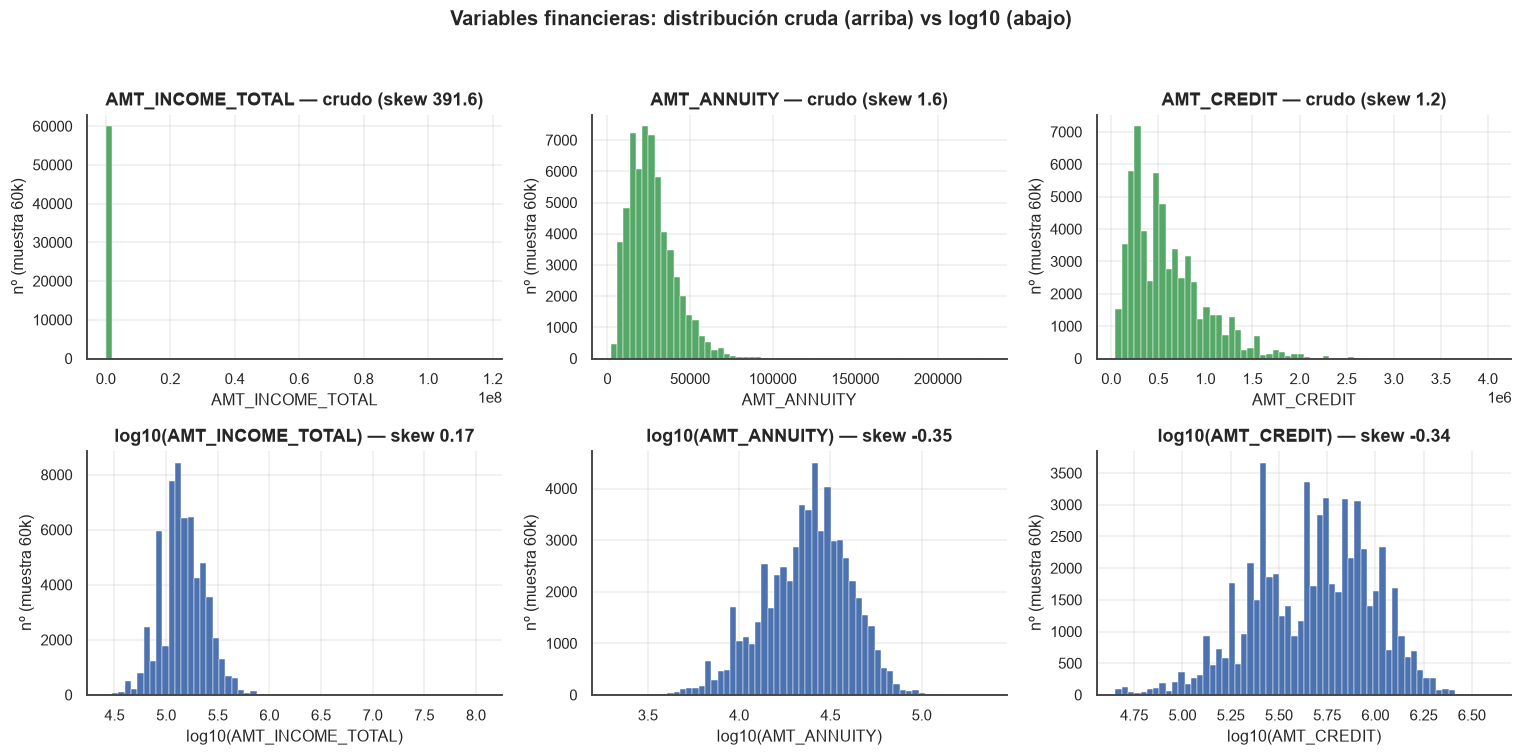

Skew crudo  ->  log10:
  AMT_INCOME_TOTAL  :    391.6  ->    0.17
  AMT_ANNUITY       :      1.6  ->   -0.35
  AMT_CREDIT        :      1.2  ->   -0.34


In [41]:
fin_log = ["AMT_INCOME_TOTAL", "AMT_ANNUITY", "AMT_CREDIT"]
samp = df.sample(60000, random_state=RNG)  # muestra para histogramas (declarado)

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
fig.suptitle("Variables financieras: distribución cruda (arriba) vs log10 (abajo)",
             fontsize=13, fontweight="bold")
for j, c in enumerate(fin_log):
    axes[0, j].hist(samp[c], bins=60, color=C_ACENTO, edgecolor="white", linewidth=0.3)
    axes[0, j].set_title(f"{c} — crudo (skew {df[c].skew():.1f})")
    axes[0, j].set_xlabel(c); axes[0, j].set_ylabel("nº (muestra 60k)")
    logv = np.log10(samp[c].clip(lower=1))
    axes[1, j].hist(logv, bins=60, color=C_PAGO, edgecolor="white", linewidth=0.3)
    axes[1, j].set_title(f"log10({c}) — skew {np.log10(df[c].clip(lower=1)).skew():.2f}")
    axes[1, j].set_xlabel(f"log10({c})"); axes[1, j].set_ylabel("nº (muestra 60k)")
for ax in axes.ravel():
    sns.despine(ax=ax)
plt.tight_layout(rect=(0, 0, 1, 0.95)); plt.show()

print("Skew crudo  ->  log10:")
for c in fin_log:
    print(f"  {c:<18}: {df[c].skew():8.1f}  ->  {np.log10(df[c].clip(lower=1)).skew():6.2f}")

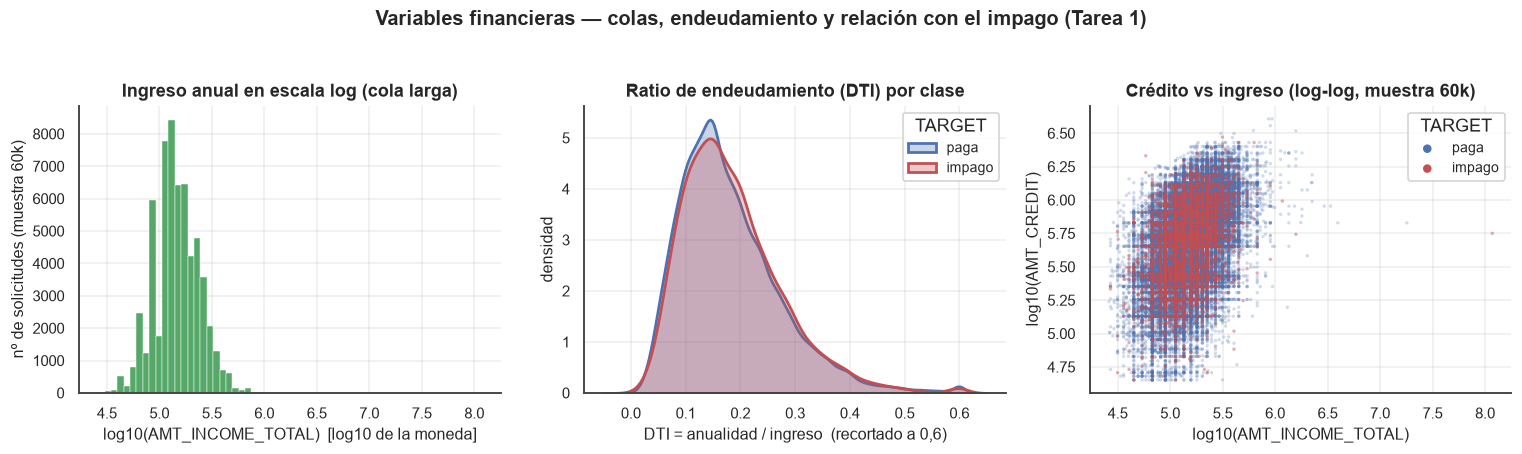

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
fig.suptitle("Variables financieras — colas, endeudamiento y relación con el impago (Tarea 1)",
             fontsize=13, fontweight="bold")
samp = df.sample(60000, random_state=RNG)  # muestra para los histogramas (declarado)

# (a) ingreso en escala log: la cola es brutal
axes[0].hist(np.log10(samp["AMT_INCOME_TOTAL"]), bins=60,
             color=C_ACENTO, edgecolor="white", linewidth=0.3)
axes[0].set_title("Ingreso anual en escala log (cola larga)")
axes[0].set_xlabel("log10(AMT_INCOME_TOTAL)  [log10 de la moneda]")
axes[0].set_ylabel("nº de solicitudes (muestra 60k)")

# (b) DTI por clase: ¿los morosos tienen ratios mayores?
for t, col, lab in [(0, C_PAGO, "paga"), (1, C_IMPAGO, "impago")]:
    sub = samp[samp["TARGET"] == t]["DTI"].clip(upper=0.6)
    sns.kdeplot(sub, ax=axes[1], label=lab, color=col, fill=True, alpha=.3, lw=1.8)
axes[1].set_title("Ratio de endeudamiento (DTI) por clase")
axes[1].set_xlabel("DTI = anualidad / ingreso  (recortado a 0,6)")
axes[1].set_ylabel("densidad")
axes[1].legend(title="TARGET")

# (c) crédito vs ingreso (log-log, muestra), coloreado por clase con colores semánticos
for t, col, lab in [(0, C_PAGO, "paga"), (1, C_IMPAGO, "impago")]:
    s = samp[samp["TARGET"] == t]
    axes[2].scatter(np.log10(s["AMT_INCOME_TOTAL"]), np.log10(s["AMT_CREDIT"]),
                    s=5, alpha=.25 if t == 0 else .45, color=col, label=lab,
                    edgecolors="none")
axes[2].set_title("Crédito vs ingreso (log-log, muestra 60k)")
axes[2].set_xlabel("log10(AMT_INCOME_TOTAL)")
axes[2].set_ylabel("log10(AMT_CREDIT)")
leg = axes[2].legend(title="TARGET", markerscale=2.5)
for lh in leg.legend_handles:
    lh.set_alpha(1)

for ax in axes:
    sns.despine(ax=ax)
plt.tight_layout(rect=(0, 0, 1, 0.95)); plt.show()

Tasa de impago por quintil de DTI (annuity/income):
                        n  tasa_impago_%
DTI_q                                   
(-0.000776, 0.104]  61500           7.20
(0.104, 0.144]      61507           7.83
(0.144, 0.186]      61494           8.13
(0.186, 0.247]      61522           8.70
(0.247, 1.876]      61476           8.52

Spread Q5-Q1 = 1.50 pp  (media global 8.07%)


C:\Users\gonde\AppData\Local\Temp\ipykernel_32608\3059328589.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["DTI_q"] = pd.qcut(df["DTI"], 5)


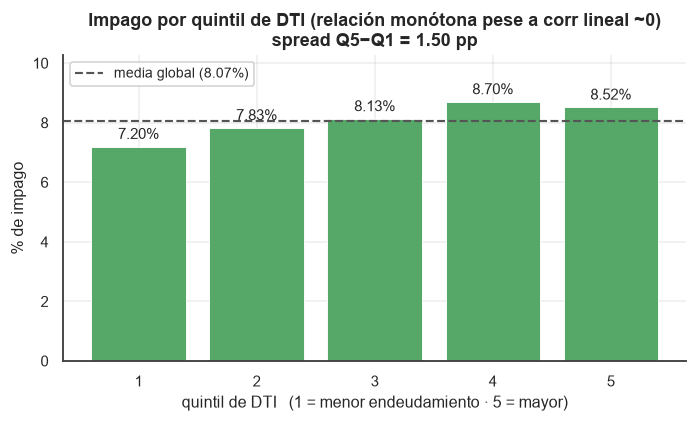

In [43]:
# La correlación LINEAL del DTI con TARGET es casi nula (~0.014). ¿Hay relación NO lineal?
# Tasa de impago por quintil de DTI (sobre el total, no muestra).
df["DTI_q"] = pd.qcut(df["DTI"], 5)
dti_tab = (df.groupby("DTI_q", observed=True)["TARGET"]
             .agg(n="count", tasa_impago="mean"))
dti_tab["tasa_impago_%"] = (dti_tab["tasa_impago"] * 100).round(2)
print("Tasa de impago por quintil de DTI (annuity/income):")
print(dti_tab[["n", "tasa_impago_%"]])
spread = (dti_tab["tasa_impago"].max() - dti_tab["tasa_impago"].min()) * 100
print(f"\nSpread Q5-Q1 = {spread:.2f} pp  "
      f"(media global {df['TARGET'].mean()*100:.2f}%)")

fig, ax = plt.subplots(figsize=(6.5, 4))
b = ax.bar([str(i+1) for i in range(len(dti_tab))], dti_tab["tasa_impago_%"],
           color=C_ACENTO, edgecolor="white", linewidth=0.6)
ax.bar_label(b, fmt="%.2f%%", padding=3, fontsize=9.5)
ax.axhline(df["TARGET"].mean()*100, ls="--", c=C_REF, lw=1.4,
           label=f"media global ({df['TARGET'].mean()*100:.2f}%)")
ax.set_title(f"Impago por quintil de DTI (relación monótona pese a corr lineal ~0)\nspread Q5−Q1 = {spread:.2f} pp")
ax.set_xlabel("quintil de DTI   (1 = menor endeudamiento · 5 = mayor)")
ax.set_ylabel("% de impago")
ax.set_ylim(0, dti_tab["tasa_impago_%"].max() * 1.18)
ax.legend(loc="upper left")
sns.despine(ax=ax)
plt.tight_layout(); plt.show()

### DTI por deciles (refinando los quintiles)

Los quintiles mostraron una relación monótona del DTI con el impago **pese a** una correlación lineal
≈ 0. Afinamos a **deciles** para ver mejor la forma de la curva, clave para decidir la saturación de
la capa custom (Tarea 1).

Tasa de impago por decil de DTI (annuity/income):
         n  rate_%
dec               
0    31645    7.14
1    29855    7.26
2    30757    7.82
3    30750    7.84
4    30757    7.88
5    30737    8.37
6    30768    8.54
7    30754    8.85
8    30726    8.84
9    30750    8.19

Spread D-max - D-min = 1.72 pp  (los quintiles daban ~1.5 pp)


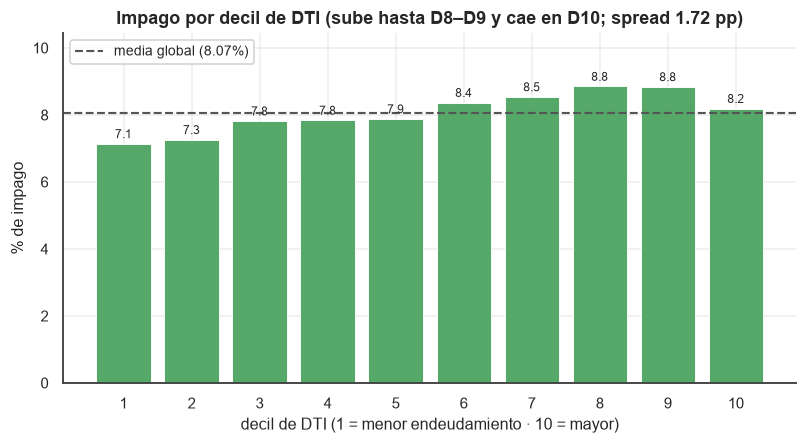

In [44]:
dd = df.loc[df["DTI"].notna(), ["DTI", "TARGET"]].copy()
dd["dec"] = pd.qcut(dd["DTI"], 10, labels=False, duplicates="drop")
dec_tab = dd.groupby("dec")["TARGET"].agg(n="count", rate="mean")
dec_tab["rate_%"] = (dec_tab["rate"] * 100).round(2)
print("Tasa de impago por decil de DTI (annuity/income):")
print(dec_tab[["n", "rate_%"]].to_string())
spread = (dec_tab["rate"].max() - dec_tab["rate"].min()) * 100
print(f"\nSpread D-max - D-min = {spread:.2f} pp  (los quintiles daban ~1.5 pp)")

fig, ax = plt.subplots(figsize=(7.5, 4.2))
b = ax.bar(np.arange(1, 11), dec_tab["rate_%"], color=C_ACENTO, edgecolor="white", linewidth=0.6)
ax.bar_label(b, fmt="%.1f", padding=2, fontsize=8)
ax.axhline(df["TARGET"].mean()*100, ls="--", c=C_REF, lw=1.4,
           label=f"media global ({df['TARGET'].mean()*100:.2f}%)")
ax.set_title(f"Impago por decil de DTI (sube hasta D8–D9 y cae en D10; spread {spread:.2f} pp)")
ax.set_xlabel("decil de DTI (1 = menor endeudamiento · 10 = mayor)")
ax.set_ylabel("% de impago"); ax.set_xticks(np.arange(1, 11))
ax.set_ylim(0, dec_tab["rate_%"].max() * 1.18); ax.legend(loc="upper left")
sns.despine(ax=ax); plt.tight_layout(); plt.show()

**Conclusión — DTI por deciles.** A resolución de decil la forma se ve mejor que en quintiles: el
impago sube de **7,14 % (D1)** de forma casi monótona hasta un máximo de **8,85 % (D8)** y luego
**cae en D10 (8,19 %)** —una **joroba**, no una recta. El spread se amplía a **1,72 pp** (vs ~1,5 pp
en quintiles). Esto refuerza la **Tarea 1**: la señal del DTI es **no lineal y no monótona en la
cola**, justo lo que la correlación de Pearson (≈ 0) no capta y lo que la red —ayudada por la capa
custom que calcula el ratio y satura la cola— sí puede aprovechar.

### Poder discriminativo: ¿qué continuas separan a pagadores de morosos?

Reunimos las continuas clave y miramos directamente cuánto separan las clases (KDE y violines
partidos por `TARGET`). El **solape** entre curvas = poder discriminativo visible: cuanto menos
solapan, más señal aporta la variable al clasificador (Tarea 3).

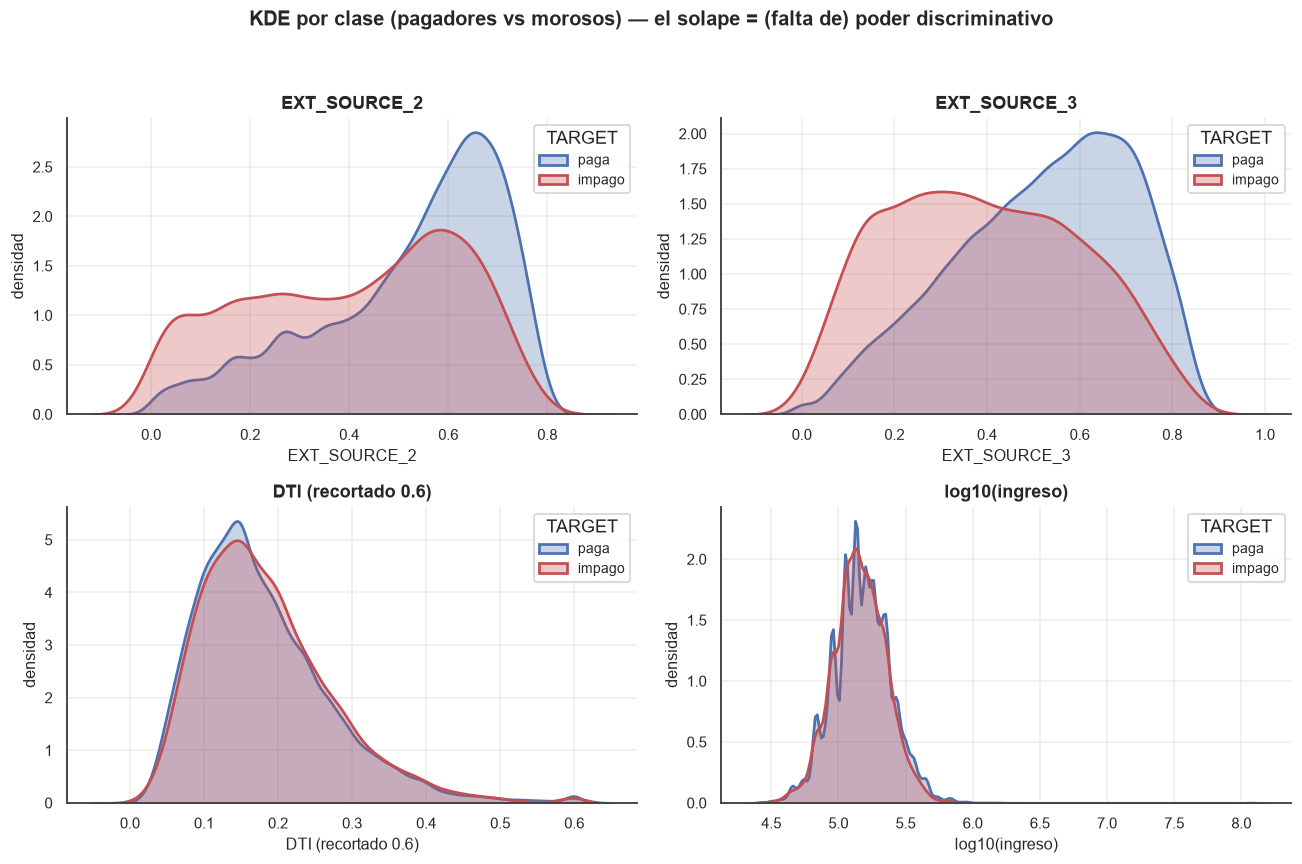

In [45]:
disc_vars = [("EXT_SOURCE_2", lambda s: s, "EXT_SOURCE_2"),
             ("EXT_SOURCE_3", lambda s: s, "EXT_SOURCE_3"),
             ("DTI", lambda s: s.clip(upper=0.6), "DTI (recortado 0.6)"),
             ("AMT_INCOME_TOTAL", lambda s: np.log10(s.clip(lower=1)), "log10(ingreso)")]
samp = df.sample(60000, random_state=RNG)  # muestra para KDE (declarado)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("KDE por clase (pagadores vs morosos) — el solape = (falta de) poder discriminativo",
             fontsize=13, fontweight="bold")
for ax, (col, fn, lab) in zip(axes.ravel(), disc_vars):
    for t, c, l in [(0, C_PAGO, "paga"), (1, C_IMPAGO, "impago")]:
        v = fn(samp.loc[samp["TARGET"] == t, col].dropna())
        sns.kdeplot(v, ax=ax, label=l, color=c, fill=True, alpha=.3, lw=1.8)
    ax.set_title(lab); ax.set_xlabel(lab); ax.set_ylabel("densidad")
    ax.legend(title="TARGET")
    sns.despine(ax=ax)
plt.tight_layout(rect=(0, 0, 1, 0.95)); plt.show()

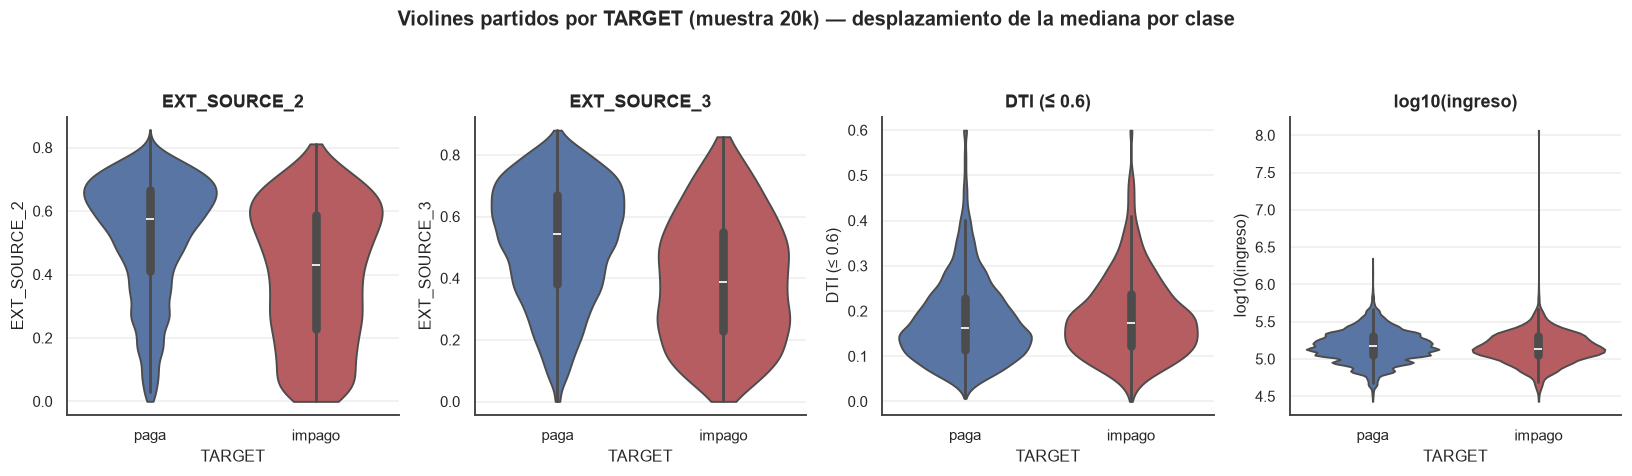

In [46]:
samp = df.sample(20000, random_state=RNG).copy()  # muestra para violines (declarado)
samp["log_income"] = np.log10(samp["AMT_INCOME_TOTAL"].clip(lower=1))
samp["DTI_clip"] = samp["DTI"].clip(upper=0.6)
vio_vars = [("EXT_SOURCE_2", "EXT_SOURCE_2"), ("EXT_SOURCE_3", "EXT_SOURCE_3"),
            ("DTI_clip", "DTI (≤ 0.6)"), ("log_income", "log10(ingreso)")]

fig, axes = plt.subplots(1, 4, figsize=(15, 4.4))
fig.suptitle("Violines partidos por TARGET (muestra 20k) — desplazamiento de la mediana por clase",
             fontsize=13, fontweight="bold")
pal = {0: C_PAGO, 1: C_IMPAGO}
for ax, (col, lab) in zip(axes, vio_vars):
    sub = samp[[col, "TARGET"]].dropna()
    sns.violinplot(data=sub, x="TARGET", y=col, hue="TARGET", palette=pal,
                   legend=False, ax=ax, cut=0)
    ax.set_title(lab); ax.set_xlabel("TARGET"); ax.set_ylabel(lab)
    ax.set_xticks([0, 1]); ax.set_xticklabels(["paga", "impago"])
    sns.despine(ax=ax)
plt.tight_layout(rect=(0, 0, 1, 0.93)); plt.show()

### Conclusiones — poder discriminativo

- **`EXT_SOURCE_2` y `EXT_SOURCE_3` son las únicas que separan visiblemente las clases:** sus KDE de
  pagadores e impagos están **desplazadas** (los morosos cargan hacia scores bajos) y en los violines
  la mediana de la clase "impago" cae claramente por debajo. Confirmación visual del ranking de MI
  (Bloque 6) y de su correlación −0,16/−0,18.
- **Las financieras solapan casi por completo:** `log10(ingreso)` y `DTI` tienen densidades por clase
  prácticamente superpuestas → poco poder discriminativo **marginal**. Coherente con su Pearson ≈ 0;
  su valor no está en separar por sí solas sino en relaciones no lineales (DTI por deciles) que la red
  puede explotar (Tareas 1 y 3).
- **Lección para la Tarea 3:** el tuner debe apoyarse en `EXT_SOURCE`; esperar señal fuerte de las
  financieras crudas es irreal —de ahí la utilidad de la capa custom que les fabrica el ratio y
  comprime sus colas.

### Conclusiones — Bloque 5

- **Colas larguísimas, sobre todo el ingreso:** `AMT_INCOME_TOTAL` tiene **skew ≈ 392** y un máximo de
  **117.000.000** que es **130× el percentil 99,9** (~900k). Confirmado que es un **caso único** (1 sola
  solicitud); por encima de 1M hay solo **250** y por encima de 10M solo **3** → la cola extrema son
  un puñado de registros, casi seguro outliers/errores de captura. Mediana 147.150 vs media 168.798:
  la media está inflada por esa cola.
- **Esto es exactamente lo que motiva la Tarea 1:** una distribución tan sesgada desperdicia capacidad
  de la red en la cola. La **saturación con exponente `x^p` (p<1)** que pide el taller comprime esos
  valores grandes y "uniformiza" la masa de clientes → tiene sentido aplicarla sobre ingreso/anualidad.
  *(Tratamiento propuesto para preprocesado: log o winsorizar el ingreso y/o recortar el outlier de 117M.)*
- **El ratio de endeudamiento DTI = annuity/income** es razonable y limpio (mediana 0,16; p99 0,48),
  buen candidato para la **capa custom** de la Tarea 1. `AMT_ANNUITY` tiene 12 nulos → cuidado con la
  **división por cero/nulos** al calcularlo en la capa (usar epsilon en el denominador).
- **Matiz importante (correlación lineal débil, ya respaldada con números):** las financieras correlacionan
  **linealmente** muy poco con `TARGET` — **ingreso −0,004, anualidad −0,013, crédito −0,030, DTI +0,014**.
  Ninguna es predictor lineal fuerte. **Pero el DTI sí tiene una relación NO lineal real y casi monótona:**
  la tasa de impago sube de **7,20 % (quintil de menor endeudamiento) a 8,70 % (Q4) y 8,52 % (Q5)** —un
  **spread de ~1,5 pp** que la correlación lineal de Pearson no capta. Lección doble para la Tarea 1: la
  capa custom (a) **calcula una división que las densas no hacen** y (b) **domestica el sesgo** con la
  saturación; y la red, al ser no lineal, **sí puede explotar esa forma monótona del DTI** que un modelo
  lineal tiraría a la basura. Aun así, la señal fuerte sigue estando en `EXT_SOURCE` (Bloque 4).

## Bloque 6 — Dependencias y síntesis final

Con cada variable ya caracterizada por separado, cerramos mirándolas juntas. La matriz de correlación
ordena quién aporta señal hacia `TARGET`, pero el chequeo decisivo es otro y apunta directo a la
Tarea 2: el de **proxies**. Si borramos `CODE_GENDER`, ¿alguna variable legítima sigue filtrando el
género por la puerta de atrás? Aquí juntamos los hilos del sesgo (Bloque 3) y de la señal externa
(Bloque 4) para ver si son, en realidad, el mismo hilo.

C:\Users\gonde\AppData\Local\Temp\ipykernel_32608\3033576450.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["GENDER_M"] = np.where(df["CODE_GENDER"]=="M", 1.0,


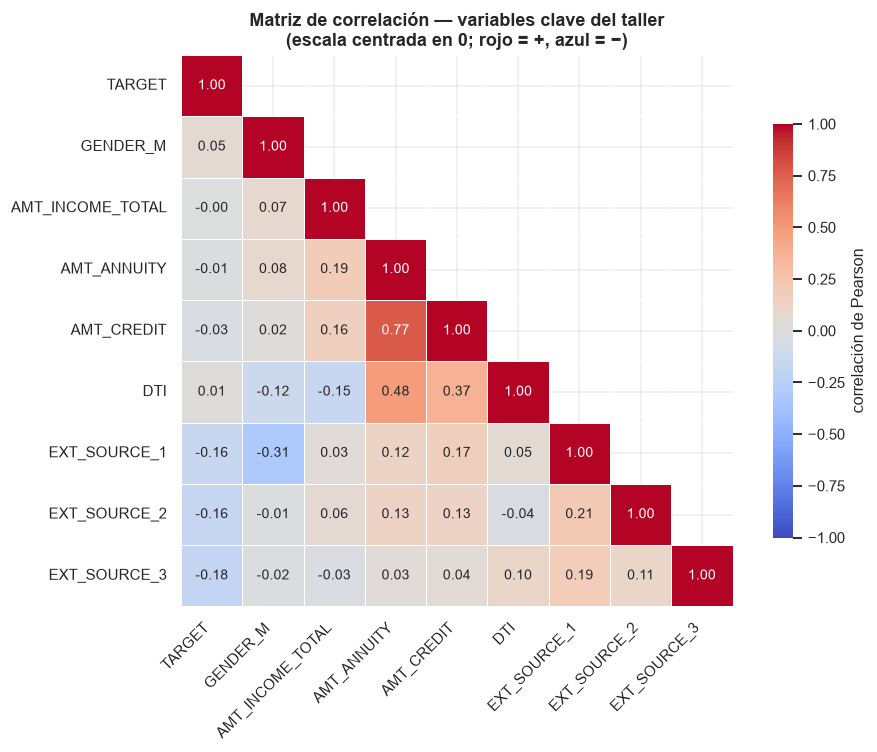

PROXIES del género - corr(GENDER_M, feature legitima):
EXT_SOURCE_1       -0.307
DTI                -0.118
EXT_SOURCE_3       -0.023
EXT_SOURCE_2       -0.015
AMT_CREDIT          0.022
AMT_INCOME_TOTAL    0.075
AMT_ANNUITY         0.077
Name: GENDER_M, dtype: float64

Media de EXT_SOURCE_1 por género (la fuga mas fuerte):
CODE_GENDER
F      0.546
M      0.407
XNA    0.529
Name: EXT_SOURCE_1, dtype: float64


In [47]:
df["GENDER_M"] = np.where(df["CODE_GENDER"]=="M", 1.0,
                          np.where(df["CODE_GENDER"]=="F", 0.0, np.nan))
KEY = ["TARGET", "GENDER_M", "AMT_INCOME_TOTAL", "AMT_ANNUITY", "AMT_CREDIT",
       "DTI", "EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]
corr = df[KEY].corr()

# Triángulo superior enmascarado para leer la matriz sin duplicar información
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5, linecolor="white",
            annot_kws={"size": 9},
            cbar_kws={"shrink": .75, "label": "correlación de Pearson"}, ax=ax)
ax.set_title("Matriz de correlación — variables clave del taller\n(escala centrada en 0; rojo = +, azul = −)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.tight_layout(); plt.show()

print("PROXIES del género - corr(GENDER_M, feature legitima):")
print(corr["GENDER_M"].drop(["GENDER_M","TARGET"]).round(3).sort_values())
print("\nMedia de EXT_SOURCE_1 por género (la fuga mas fuerte):")
print(df.groupby("CODE_GENDER")["EXT_SOURCE_1"].mean().round(3))

### Más allá de Pearson: comparación de medidas de dependencia (Tarea 2)

La matriz anterior solo usa **Pearson**, que únicamente ve líneas rectas. La FAIR loss de la Tarea 2
necesita una medida que valga cero *solo* bajo independencia real (incluida la no lineal). Comparamos
medidas de la teoría de dependencia —**Pearson, Spearman, correlación de distancias (dCor) e
información mutua**— para ver qué capta cada una y cuál conviene. *(Omitimos la cross-entropy: es una
función de pérdida, no una medida de dependencia entre variables.)*

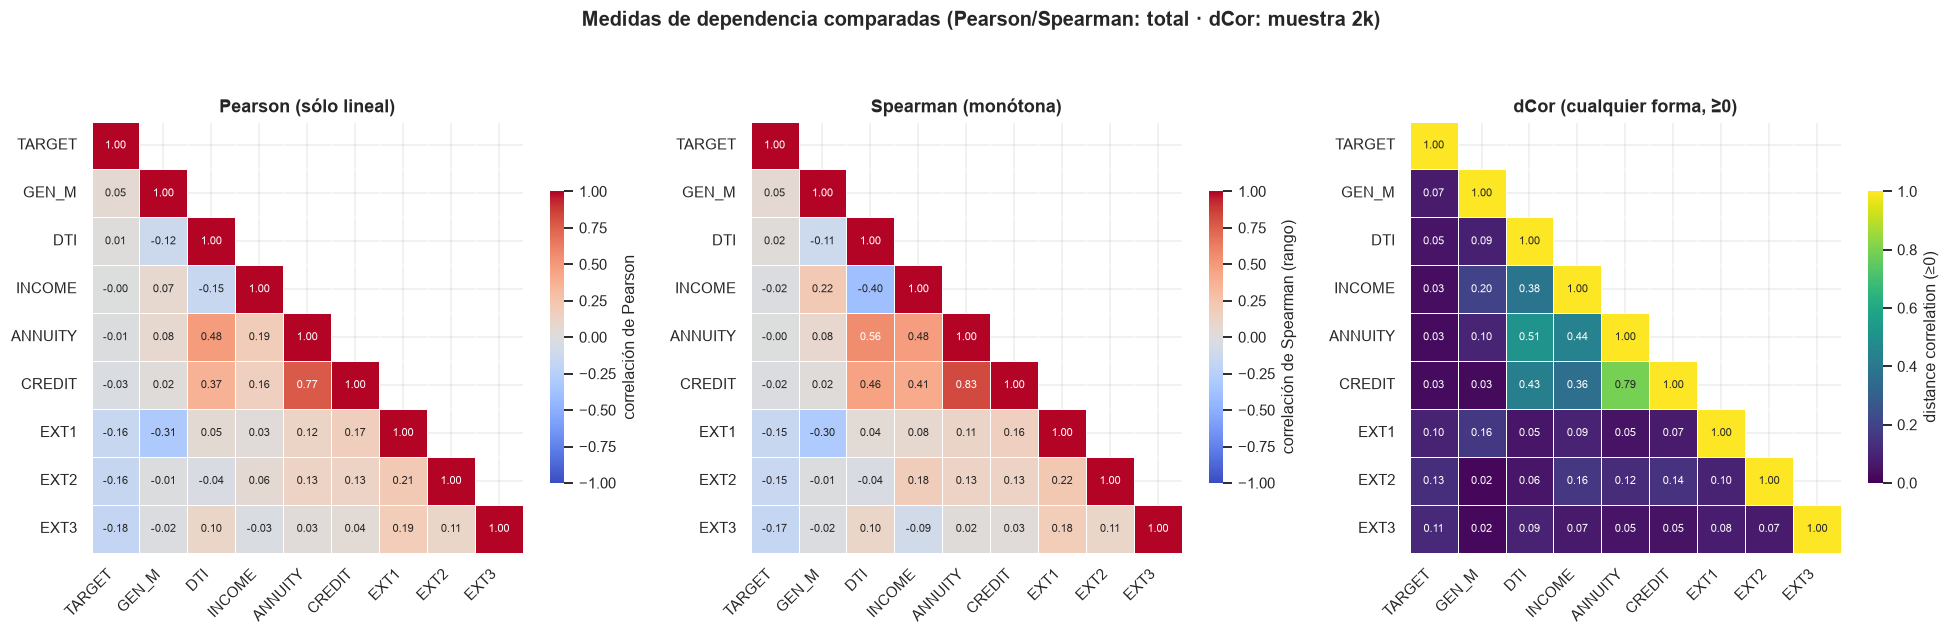

Dependencia con TARGET (Pearson / Spearman: total · dCor: muestra):
  GENDER_M         pearson +0.055  spearman +0.055  dCor 0.074
  DTI              pearson +0.014  spearman +0.018  dCor 0.052
  AMT_INCOME_TOTAL pearson -0.004  spearman -0.018  dCor 0.033
  AMT_ANNUITY      pearson -0.013  spearman -0.000  dCor 0.027
  AMT_CREDIT       pearson -0.030  spearman -0.018  dCor 0.029
  EXT_SOURCE_1     pearson -0.155  spearman -0.151  dCor 0.096
  EXT_SOURCE_2     pearson -0.160  spearman -0.147  dCor 0.129
  EXT_SOURCE_3     pearson -0.179  spearman -0.166  dCor 0.114


In [48]:
def distance_correlation(x, y):
    """dCor sobre dos vectores 1D (numpy puro). 0 <=> independencia (incl. no lineal)."""
    x = np.asarray(x, float).reshape(-1, 1); y = np.asarray(y, float).reshape(-1, 1)
    n = len(x)
    a = np.abs(x - x.T); b = np.abs(y - y.T)
    A = a - a.mean(0) - a.mean(1)[:, None] + a.mean()
    B = b - b.mean(0) - b.mean(1)[:, None] + b.mean()
    dcov2 = (A * B).sum() / (n * n); vx = (A * A).sum() / (n * n); vy = (B * B).sum() / (n * n)
    return float(np.sqrt(max(dcov2, 0)) / np.sqrt(np.sqrt(vx * vy))) if vx * vy > 0 else 0.0

DKEY = ["TARGET", "GENDER_M", "DTI", "AMT_INCOME_TOTAL", "AMT_ANNUITY", "AMT_CREDIT",
        "EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]
labels = ["TARGET", "GEN_M", "DTI", "INCOME", "ANNUITY", "CREDIT", "EXT1", "EXT2", "EXT3"]

pear = df[DKEY].corr()                      # total, pairwise
spear = df[DKEY].corr(method="spearman")    # total, pairwise
# dCor: matrices n x n -> O(n^2); muestra 2000 con imputación por mediana (declarado)
samp = df[DKEY].sample(2000, random_state=RNG).copy()
samp = samp.fillna(samp.median())
dc = pd.DataFrame(np.eye(len(DKEY)), index=DKEY, columns=DKEY)
for i in range(len(DKEY)):
    for j in range(i + 1, len(DKEY)):
        v = distance_correlation(samp.iloc[:, i], samp.iloc[:, j])
        dc.iloc[i, j] = dc.iloc[j, i] = v

fig, axes = plt.subplots(1, 3, figsize=(18, 5.6))
fig.suptitle("Medidas de dependencia comparadas (Pearson/Spearman: total · dCor: muestra 2k)",
             fontsize=13, fontweight="bold")
mask = np.triu(np.ones((len(DKEY), len(DKEY)), bool), k=1)
panels = [(axes[0], pear, "Pearson (sólo lineal)", "coolwarm", -1, "correlación de Pearson"),
          (axes[1], spear, "Spearman (monótona)", "coolwarm", -1, "correlación de Spearman (rango)"),
          (axes[2], dc, "dCor (cualquier forma, ≥0)", "viridis", 0, "distance correlation (≥0)")]
for ax, M, name, cmap, vmin, clab in panels:
    sns.heatmap(M, mask=mask, annot=True, fmt=".2f", cmap=cmap,
                center=0 if vmin < 0 else None, vmin=vmin, vmax=1, square=True,
                linewidths=0.5, linecolor="white", annot_kws={"size": 7.5},
                cbar_kws={"shrink": .6, "label": clab}, ax=ax, xticklabels=labels, yticklabels=labels)
    ax.set_title(name)
    ax.set_xticklabels(labels, rotation=45, ha="right"); ax.set_yticklabels(labels, rotation=0)
plt.tight_layout(rect=(0, 0, 1, 0.94)); plt.show()

print("Dependencia con TARGET (Pearson / Spearman: total · dCor: muestra):")
for f in DKEY[1:]:
    print(f"  {f:<16} pearson {pear.loc[f,'TARGET']:+.3f}  "
          f"spearman {spear.loc[f,'TARGET']:+.3f}  dCor {dc.loc[f,'TARGET']:.3f}")

### Conclusiones — qué capta cada medida

- **Para `EXT_SOURCE`, las tres medidas coinciden en señalarlas como el vínculo más fuerte con
  `TARGET`** (Pearson/Spearman 0,15–0,18; dCor 0,10–0,13): relación **limpia y monótona**, sin
  no-linealidad oculta que Pearson se pierda (la dCor algo menor es efecto del muestreo/imputación, no
  señal escondida). Cualquier medida las detecta.
- **Para `DTI` e ingreso, dCor desenmascara señal que Pearson niega:** `DTI`↔`TARGET` da Pearson
  **+0,014** pero dCor **0,052** (≈ 4×); ingreso da Pearson **−0,004** y dCor **0,033**. La dependencia
  es **no lineal** (la joroba de los deciles) y solo una medida tipo distancia/MI la ve → confirma por
  qué la red puede exprimir el DTI (Tarea 1) aunque un modelo lineal lo descarte.
- **Proxy de género `GEN_M`↔`TARGET`:** Pearson **+0,055** vs dCor **0,074** → la dependencia
  género↔riesgo tampoco es puramente lineal.
- **Recomendación para la FAIR loss (Tarea 2):** como `CODE_GENDER` es **binaria**, Pearson/HSIC sobre
  la predicción bastan para **penalizar** (son diferenciables); pero **dCor/MI son la medida correcta
  para auditar**, porque capturan la parte no lineal que Pearson declara "neutral". Regla: penalizar
  con correlación/HSIC, **reportar con dCor/MI + group gap**.

### Ranking de señal: información mutua con `TARGET`

Vista *qué tipo* de dependencia capta cada medida, queda ordenar a los candidatos por **cuánta**
señal aportan. La información mutua (modelo-agnóstica) mide la dependencia en *nats* sin asumir forma
funcional, así que sirve de **ranking de poder predictivo** de cada variable clave frente a `TARGET`
(`mutual_info_classif`, muestra de 50k filas con imputación por mediana declarada).

Información mutua con TARGET (nats, muestra 50k, imputación mediana):
EXT_SOURCE_2        0.0141
EXT_SOURCE_3        0.0121
AMT_ANNUITY         0.0117
AMT_CREDIT          0.0071
EXT_SOURCE_1        0.0062
DTI                 0.0026
AMT_INCOME_TOTAL    0.0023
GENDER_M            0.0020
N_EXT_MISSING       0.0004


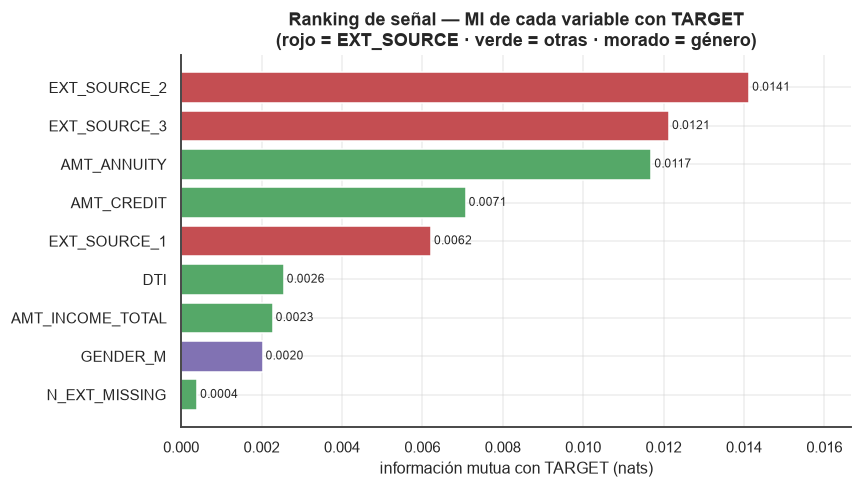

In [49]:
from sklearn.feature_selection import mutual_info_classif

mi_feats = ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3", "DTI", "AMT_INCOME_TOTAL",
            "AMT_ANNUITY", "AMT_CREDIT", "GENDER_M", "N_EXT_MISSING"]
# muestra 50k con imputación por mediana (declarado); discretas: género y nº de ausentes
samp = df.dropna(subset=["GENDER_M"]).sample(50000, random_state=RNG)
Xmi = samp[mi_feats].copy()
for c in mi_feats:
    Xmi[c] = Xmi[c].fillna(Xmi[c].median())
disc = [c in ("GENDER_M", "N_EXT_MISSING") for c in mi_feats]
mi = mutual_info_classif(Xmi, samp["TARGET"], discrete_features=disc, random_state=RNG)
mi_s = pd.Series(mi, index=mi_feats).sort_values(ascending=False)
print("Información mutua con TARGET (nats, muestra 50k, imputación mediana):")
print(mi_s.round(4).to_string())

fig, ax = plt.subplots(figsize=(8, 4.6))
colors = [C_IMPAGO if f.startswith("EXT_SOURCE")
          else (C_M if f == "GENDER_M" else C_ACENTO) for f in mi_s.index]
b = ax.barh(mi_s.index[::-1], mi_s.values[::-1], color=colors[::-1], edgecolor="white")
ax.bar_label(b, fmt="%.4f", padding=2, fontsize=8)
ax.set_title("Ranking de señal — MI de cada variable con TARGET\n"
             "(rojo = EXT_SOURCE · verde = otras · morado = género)")
ax.set_xlabel("información mutua con TARGET (nats)")
ax.set_xlim(0, mi_s.max() * 1.18)
sns.despine(ax=ax); plt.tight_layout(); plt.show()

### Conclusiones — ranking de información mutua

- **`EXT_SOURCE_2` (0,0141) y `EXT_SOURCE_3` (0,0121) lideran el ranking de MI**, por encima del resto
  → confirman, **sin asumir linealidad**, que la señal predictiva vive en las fuentes externas
  (refuerza Tarea 3).
- **`EXT_SOURCE_1` cae al 5.º puesto (0,0062), por debajo de `AMT_ANNUITY` (0,0117) y `AMT_CREDIT`
  (0,0071):** su MI se diluye porque falta en el **56 %** de las filas y la imputación por mediana
  inyecta ruido. Lección Tarea 4: la *calidad* (no solo la correlación bruta) de `EXT_SOURCE_1` está
  comprometida; mantener su flag de ausencia es doblemente útil.
- **`GENDER_M` tiene MI casi nula con TARGET (0,0020):** el género **por sí mismo** aporta poquísima
  información sobre el impago —consistente con que el gap se explica vía el proxy `EXT_SOURCE_1`, no
  por el género directamente (Tarea 2).
- **`N_EXT_MISSING` (0,0004)** aporta poca MI marginal, pero el Bloque 4 mostró que su relación con el
  impago es monótona; su valor es como **feature de incertidumbre** (Tarea 4), no como predictor
  fuerte aislado.

In [50]:
# ¿El group gap de impago (M-F) es "género" o es el PROXY EXT_SOURCE_1 disfrazado?
# Test: controlar por nivel de EXT_SOURCE_1 (quintiles) y ver si el gap sobrevive.
gg = df[df["CODE_GENDER"].isin(["F", "M"])].copy()
sub = gg[gg["EXT_SOURCE_1"].notna()].copy()   # solo donde el proxy es observable (~134k filas)

raw_sub = (sub.loc[sub.CODE_GENDER == "M", "TARGET"].mean()
           - sub.loc[sub.CODE_GENDER == "F", "TARGET"].mean()) * 100
print(f"Gap M-F bruto en el subconjunto con EXT_SOURCE_1 presente: {raw_sub:+.2f} pp  (n={len(sub):,})")

sub["e1_q"] = pd.qcut(sub["EXT_SOURCE_1"], 5)
tab = (sub.groupby(["e1_q", "CODE_GENDER"], observed=True)["TARGET"].mean().unstack() * 100)
tab["gap_pp"] = tab["M"] - tab["F"]
print("\nTasa de impago por quintil de EXT_SOURCE_1 y género (controlando el proxy):")
print(tab.round(2))

w = sub.groupby("e1_q", observed=True).size()
gap_ctrl = (tab["gap_pp"] * w).sum() / w.sum()
print(f"\nGap M-F PROMEDIO ponderado DENTRO de cada quintil de EXT_SOURCE_1: {gap_ctrl:+.2f} pp")
print(f"  -> el gap bruto ({raw_sub:+.2f} pp) se reduce a ~{gap_ctrl:+.2f} pp al controlar por el proxy.")

Gap M-F bruto en el subconjunto con EXT_SOURCE_1 presente: +2.51 pp  (n=134,131)

Tasa de impago por quintil de EXT_SOURCE_1 y género (controlando el proxy):
CODE_GENDER                        F      M  gap_pp
e1_q                                               
(0.013600000000000001, 0.296]  15.26  14.06   -1.19
(0.296, 0.438]                  8.99   8.30   -0.69
(0.438, 0.573]                  6.25   6.65    0.40
(0.573, 0.71]                   4.67   5.07    0.40
(0.71, 0.963]                   2.86   4.05    1.19

Gap M-F PROMEDIO ponderado DENTRO de cada quintil de EXT_SOURCE_1: +0.02 pp
  -> el gap bruto (+2.51 pp) se reduce a ~+0.02 pp al controlar por el proxy.


### El canal-proxy en imágenes: ¿por dónde se cuela el género? (Tarea 2)

El test de control mostró que el gap de género casi desaparece al condicionar por `EXT_SOURCE_1`. Lo
visualizamos: ¿difiere la distribución de las variables predictivas **dentro de cada género**?,
¿hereda el modelo un **riesgo** distinto por género?, y ¿dónde se concentra el gap en la rejilla
género × score?

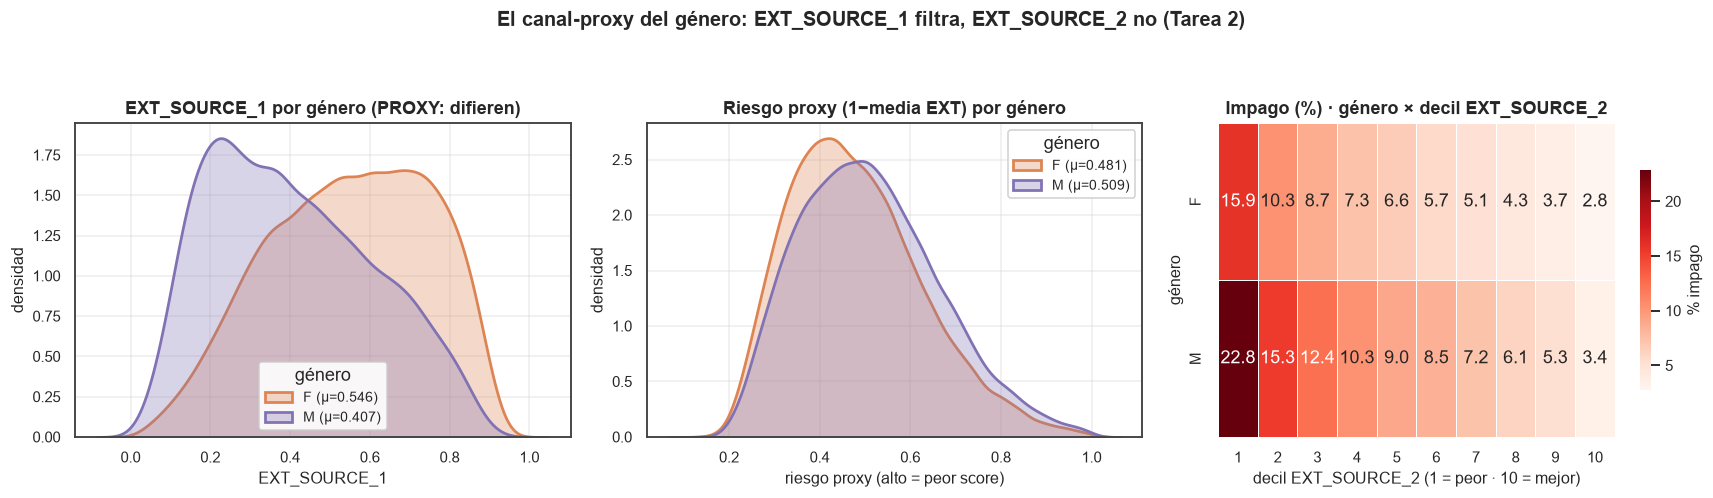

Media EXT_SOURCE_1  F vs M: {'F': 0.546, 'M': 0.407}
Media EXT_SOURCE_2  F vs M: {'F': 0.516, 'M': 0.511}
Gap M-F por decil EXT_SOURCE_2 (pp): {0: 7.0, 1: 5.0, 2: 3.8, 3: 3.0, 4: 2.4, 5: 2.7, 6: 2.1, 7: 1.8, 8: 1.6, 9: 0.6}


In [51]:
g = df[df["CODE_GENDER"].isin(["F", "M"])].copy()
g["risk_proxy"] = 1 - g[EXT].mean(axis=1)            # alto = peor score externo
samp = g.sample(60000, random_state=RNG)             # muestra para KDE (declarado)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
fig.suptitle("El canal-proxy del género: EXT_SOURCE_1 filtra, EXT_SOURCE_2 no (Tarea 2)",
             fontsize=13, fontweight="bold")

# (a) EXT_SOURCE_1 por género -> distribuciones DISTINTAS => proxy
for k in ["F", "M"]:
    mu = g.loc[g.CODE_GENDER == k, "EXT_SOURCE_1"].mean()
    sns.kdeplot(samp.loc[samp.CODE_GENDER == k, "EXT_SOURCE_1"].dropna(), ax=axes[0],
                label=f"{k} (μ={mu:.3f})", color=GEN_COLORS[k], fill=True, alpha=.3, lw=1.8)
axes[0].set_title("EXT_SOURCE_1 por género (PROXY: difieren)")
axes[0].set_xlabel("EXT_SOURCE_1"); axes[0].set_ylabel("densidad"); axes[0].legend(title="género")

# (b) riesgo proxy (1 - media EXT) por género -> riesgo heredado
for k in ["F", "M"]:
    mu = g.loc[g.CODE_GENDER == k, "risk_proxy"].mean()
    sns.kdeplot(samp.loc[samp.CODE_GENDER == k, "risk_proxy"].dropna(), ax=axes[1],
                label=f"{k} (μ={mu:.3f})", color=GEN_COLORS[k], fill=True, alpha=.3, lw=1.8)
axes[1].set_title("Riesgo proxy (1−media EXT) por género")
axes[1].set_xlabel("riesgo proxy (alto = peor score)"); axes[1].set_ylabel("densidad")
axes[1].legend(title="género")

# (c) heatmap tasa de impago: género x decil de EXT_SOURCE_2 (variable neutra)
sub = g[g["EXT_SOURCE_2"].notna()].copy()
sub["dec"] = pd.qcut(sub["EXT_SOURCE_2"], 10, labels=False)
heat = sub.groupby(["CODE_GENDER", "dec"])["TARGET"].mean().unstack() * 100
sns.heatmap(heat, annot=True, fmt=".1f", cmap="Reds", ax=axes[2],
            cbar_kws={"shrink": .7, "label": "% impago"}, linewidths=0.5, linecolor="white")
axes[2].set_title("Impago (%) · género × decil EXT_SOURCE_2")
axes[2].set_xticklabels([str(i) for i in range(1, 11)])
axes[2].set_xlabel("decil EXT_SOURCE_2 (1 = peor · 10 = mejor)"); axes[2].set_ylabel("género")
plt.tight_layout(rect=(0, 0, 1, 0.92)); plt.show()

print("Media EXT_SOURCE_1  F vs M:", g.groupby("CODE_GENDER")["EXT_SOURCE_1"].mean().round(3).to_dict())
print("Media EXT_SOURCE_2  F vs M:", g.groupby("CODE_GENDER")["EXT_SOURCE_2"].mean().round(3).to_dict())
print("Gap M-F por decil EXT_SOURCE_2 (pp):", (heat.loc["M"] - heat.loc["F"]).round(1).to_dict())

### Conclusiones — el canal-proxy en imágenes

- **`EXT_SOURCE_1` SÍ es proxy de género: sus distribuciones por sexo están desplazadas** (mujeres
  μ = 0,546 vs hombres μ = 0,407). Es el canal físico por el que el género se cuela aunque se borre
  `CODE_GENDER`, exactamente lo que la FAIR loss debe vigilar.
- **`EXT_SOURCE_2` NO es proxy: misma distribución por género** (F 0,516 vs M 0,511). Por eso, en su
  rejilla género × decil **el gap M−F persiste en todos los deciles** (≈ +7,0 pp en el peor decil →
  +0,6 pp en el mejor): condicionar por una variable *neutra* no borra el sesgo. Contraste clave: el
  gap solo se disuelve al condicionar por el **verdadero** proxy `EXT_SOURCE_1` (test del bloque
  anterior, +2,51 → +0,02 pp).
- **El riesgo proxy heredado difiere por género** (mujeres 0,481 vs hombres 0,509): los hombres caen
  sistemáticamente en peor score externo, así que un modelo que use `EXT_SOURCE` **heredará** esa
  diferencia aunque nunca vea el género.
- **Implicación operativa Tarea 2:** la penalización `Dep(ŷ, CODE_GENDER)` tiene que actuar sobre el
  canal `EXT_SOURCE_1` (donde está la fuga), y la auditoría debe medirse con cuidado: condicionar por
  la variable equivocada (`EXT_SOURCE_2`) daría la falsa impresión de que el sesgo es irreducible.

### Conclusiones — Bloque 6

- **`EXT_SOURCE` domina la señal hacia `TARGET`** (−0,16/−0,16/−0,18); el resto de variables del taller
  están casi planas frente al objetivo. El modelo vivirá, sobre todo, de las fuentes externas.
- **Hallazgo crítico para la Tarea 2 — proxy de género:** `EXT_SOURCE_1` correlaciona **−0,31 con el
  género** (hombres media 0,407 vs mujeres 0,546). Es decir, **aunque borres `CODE_GENDER`, el género
  se filtra por `EXT_SOURCE_1`** (y algo por `DTI`, −0,12). Esto confirma en *nuestros datos* la tesis
  central de la FAIR loss: *borrar la columna sensible no basta, hay que penalizar la dependencia* —
  porque el optimizador reconstruye el género desde la variable más predictiva que tenemos.
- **El proxy NO solo correlaciona: EXPLICA casi todo el group gap de impago (test de control).** El gap
  bruto M−F en el subconjunto donde `EXT_SOURCE_1` es observable es **+2,51 pp**, pero al **controlar por
  el nivel de `EXT_SOURCE_1` (quintiles), el gap promedio dentro de cada quintil se desploma a ≈ +0,02 pp**
  (incluso cambia de signo: −1,2 pp en el peor quintil de score, +1,2 pp en el mejor). Traducción para la
  Tarea 2: la diferencia de impago entre géneros **no es "género per se", es `EXT_SOURCE_1`** (los hombres
  tienen sistemáticamente peor score externo). Por eso penalizar `Dep(ŷ, CODE_GENDER)` **tiene que actuar
  sobre el canal `EXT_SOURCE_1`**: ahí está físicamente la fuga. *(Caveat honesto: el control es sobre las
  ~134k filas con `EXT_SOURCE_1` presente, el 44 % del total; en el 56 % restante el proxy no es observable.)*
- Las financieras correlacionan entre sí lo esperable (crédito↔anualidad alto) pero poco con el objetivo.

#### Tabla síntesis: hallazgo → tarea → implicación de diseño

| # | Hallazgo (número real) | Tarea afectada | Implicación de diseño |
|---|------------------------|----------------|------------------------|
| 1 | Impago **8,07 %** (ratio 11,4:1); clasificador trivial "todo paga" acierta **91,93 %** | 2,3,4 | Métrica = **AUC / recall**, no accuracy; `class_weight`; más incertidumbre esperable en la clase impago |
| 2 | Centinela **365243** en `DAYS_EMPLOYED` en **55.374 filas (18,01 %)**, casi todos pensionistas (impagan **5,40 % vs 8,66 %**); ingreso máx **117M = 130× p99.9** | **1,4** | Convertir 365243→`NaN` + flag antes de normalizar la antigüedad; la *ausencia de empleo* informa; recortar/log el ingreso |
| 3 | Group gap base **M 10,14 % vs F 7,00 % (+3,14 pp)**, pero **≈ 0 al controlar por `EXT_SOURCE_1`** (+2,51→+0,02 pp) | **2** | El gap es el **proxy**, no "género"; penalizar `Dep(ŷ, género)` debe morder el canal `EXT_SOURCE_1`; reportar group gap; 4 `XNA` a tratar |
| 4 | **`EXT_SOURCE_1` ↔ género = −0,31** (proxy, F μ 0,546 / M μ 0,407); **`EXT_SOURCE_2` neutra** (F 0,516 / M 0,511) | **2** | Borrar `CODE_GENDER` **no** elimina el sesgo → FAIR loss necesaria; auditar condicionando por el proxy **real** (`EXT_SOURCE_1`), nunca por la variable neutra |
| 5 | Nulos EXT **56 % / 20 % / 0,2 %**; **NO faltan juntas** (corr de flags ≈ 0); la **ausencia predice** impago (1→2 fuentes: 8,2 %→9,9 %) | **4** | Crear flags `*_missing` antes de imputar; `N_EXT_MISSING` es gradiente **real** de incertidumbre; cruzar imputación ↔ `Var[p]` |
| 6 | `EXT_SOURCE` = únicas predictivas fuertes: relación **monótona, impago ~18–20 %→3 % por decil (≈6×)**; lideran la **MI** (`EXT_SOURCE_2` 0,0141 > `_3` 0,0121); complementarias (r 0,1–0,2) | 1,3,4 | Conservar las 3; el tuner debe aprovechar esta señal limpia; no esperar milagros de las financieras |
| 7 | **dCor desenmascara la no-linealidad que Pearson niega:** DTI Pearson **+0,014** vs dCor **0,052** (≈4×); ingreso **−0,004** vs dCor **0,033** | 1,2 | Penalizar la FAIR loss con correlación/HSIC (sensible binaria), pero **auditar con dCor/MI**: ven la dependencia no lineal que Pearson llama "neutral" |
| 8 | Ingreso **skew 392**, máx **117M = 130× p99.9** (caso único, 3 casos >10M); DTI dibuja una **joroba** 7,14 % (D1)→8,85 % (D8)→8,19 % (D10), limpio (med 0,16) | **1** | Saturación `x^p` (p<1) sobre ingreso/anualidad; ratio annuity/income con **epsilon** (12 nulos en annuity); la red puede explotar la forma no lineal/no monótona del DTI |

> **Cierre — la historia que cuentan los datos.** El recorrido encaja pieza a pieza con las 4 tareas.
> Antes de medir nada hubo que **limpiar la mirada**: un centinela oculto (365243 en `DAYS_EMPLOYED`,
> el 18 % de las filas) y una cola de ingresos imposible (117M) recordaron que sin chequeo de calidad
> las métricas mienten. Ya con datos fiables, partimos de un **desbalance fuerte** (8 % de impagos) que
> descarta la accuracy y fija el eje de precisión del problema. Al preguntar de quién es ese impago
> aparece un **sesgo de género real** (+3,14 pp)… que al rascar resulta no ser género, sino el **proxy
> `EXT_SOURCE_1`**: el gap casi desaparece al controlar por ese score —pero NO al condicionar por
> `EXT_SOURCE_2`, que es neutra entre sexos, así que auditar con la variable equivocada daría la falsa
> impresión de un sesgo irreducible. Y ese mismo `EXT_SOURCE` que filtra el género es, a la vez, **la
> única señal predictiva fuerte** (relación monótona ≈6× por decil, líder en información mutua) y la más
> **ausente** —pero sus huecos no faltan en bloque, sino dispersos, de modo que el contador de fuentes
> ausentes es un gradiente **real** de incertidumbre. Las **financieras**, en cambio, casi no
> correlacionan en lineal, pero la correlación de distancias **desenmascara** lo que Pearson niega: una
> **forma no lineal** (el DTI dibuja una joroba que sube hasta D8 y cae en D10) que motiva domesticarlas
> con la capa custom y su saturación. La moraleja de diseño es coherente: la FAIR loss debe
> **localizarse** sobre el canal `EXT_SOURCE_1`, el tuner debe **explotar** la señal externa, la capa
> custom debe **comprimir** las colas financieras y el modelo de incertidumbre debe **vigilar** dónde se
> imputaron las fuentes. Ningún hallazgo es genérico: todos salen de los números de estas 307k solicitudes.